# PINN Heston 3D

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    torch.set_float32_matmul_precision('high')

Using device: cpu


/Users/romainchevrot/.Python_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fast Heston Pricer

In [3]:
class HestonPricer:
    """
    Vectorised Heston call pricer via Gil-Pelaez Fourier inversion.
    Uses pre-computed Gauss-Legendre nodes on [0, U].

    C(S, K, tau) = S * P1  -  K * exp(-r*tau) * P2
    """

    def __init__(self, r, kappa, theta, sigma, rho, U=120.0, n_pts=64):
        self.r, self.kappa, self.theta = r, kappa, theta
        self.sigma, self.rho           = sigma, rho
        x, w       = np.polynomial.legendre.leggauss(n_pts)
        self.u     = 0.5 * U * (x + 1.0)
        self.w     = 0.5 * U * w

    def _cf(self, u, v, tau, j):
        """Heston characteristic function for P_j, fully vectorised."""
        kappa, theta = self.kappa, self.theta
        sigma, rho, r = self.sigma, self.rho, self.r
        if j == 1:
            u_j, b_j = 0.5, kappa - rho * sigma
        else:
            u_j, b_j = -0.5, kappa

        a  = kappa * theta
        iu = 1j * u
        d  = np.sqrt((rho * sigma * iu - b_j)**2
                     - sigma**2 * (2 * u_j * iu - u**2))
        bp = b_j - rho * sigma * iu
        g  = (bp + d) / (bp - d)

        C  = (r * iu * tau
              + (a / sigma**2) * (
                    (bp + d) * tau
                    - 2.0 * np.log((1.0 - g * np.exp(d * tau)) / (1.0 - g))
              ))
        D  = ((bp + d) / sigma**2
              * (1.0 - np.exp(d * tau)) / (1.0 - g * np.exp(d * tau)))

        return np.exp(C + D * v)

    def _P_j(self, j, S_arr, K_arr, v, tau):
        """
        P_j for arrays of S and K (same length).
        Returns array of shape (N,).
        """
        u       = self.u                                             # (n_pts,)
        cf_vals = self._cf(u, v, tau, j)
        logS    = np.log(np.maximum(S_arr, 1e-12))                  # (N,)
        logK    = np.log(np.maximum(K_arr, 1e-12))                  # (N,)

        # outer product: exp(i*u*(logS - logK))  ->  (N, n_pts)
        phase = np.exp(1j * np.outer(logS - logK, u))
        integrand = (phase * cf_vals[np.newaxis, :] / (1j * u[np.newaxis, :])).real
        return 0.5 + (integrand @ self.w) / np.pi                   # (N,)

    def price(self, S, K, v, tau, option_type="call"):
        S   = max(float(S), 1e-12)
        v   = max(float(v), 1e-12)
        tau = max(float(tau), 0.0)
        K   = float(K)

        if tau < 1e-8:
            c = max(S - K, 0.0)
            return c if option_type == "call" else max(c - S + K * math.exp(-self.r * tau), 0.0)

        if math.log(S / K) < -2.0:
            return 0.0 if option_type == "call" else max(K * math.exp(-self.r * tau) - S, 0.0)

        S_a = np.array([S]); K_a = np.array([K])
        P1  = self._P_j(1, S_a, K_a, v, tau)[0]
        P2  = self._P_j(2, S_a, K_a, v, tau)[0]
        c   = S * P1 - K * math.exp(-self.r * tau) * P2
        c   = max(c, 0.0)
        return c if option_type == "call" else max(c - S + K * math.exp(-self.r * tau), 0.0)

    def price_grid(self, S_arr, K, v, tau):
        """
        Vectorised: price len(S_arr) calls at once. K is scalar.
        Returns numpy array of call prices.
        """
        S_arr = np.maximum(np.asarray(S_arr, dtype=float), 1e-12)
        K_f   = float(K)

        if tau < 1e-8:
            return np.maximum(S_arr - K_f, 0.0)

        # Deep-OTM calls (log(S/K) < -2) are set to 0: the true price is negligible and GL quadrature aliases at large moneyness ratios.
        log_m   = np.log(S_arr / K_f)          
        otm     = log_m < -2.0                 

        prices  = np.zeros_like(S_arr)
        valid   = ~otm

        if valid.any():
            S_v = S_arr[valid]
            K_a = np.full_like(S_v, K_f)
            P1  = self._P_j(1, S_v, K_a, v, tau)
            P2  = self._P_j(2, S_v, K_a, v, tau)
            prices[valid] = np.maximum(S_v * P1 - K_f * math.exp(-self.r * tau) * P2, 0.0)

        return prices

## PINN Class 

In [ ]:
class PINN_Heston_Continuous(nn.Module):
    def __init__(
        self,
        K, r, kappa, theta, sigma, rho, T,
        S_min, S_max, v_min, v_max, t_min, t_max,
        hidden_layers,
        activation_fun=nn.Tanh,
        loss_weights=None,
        atm_fraction=0.4,
        atm_bandwidth=0.25,
    ):
        super().__init__()

        # PDE parameters
        self.K, self.r         = K, r
        self.kappa, self.theta = kappa, theta
        self.sigma, self.rho   = sigma, rho
        self.T                 = T

        # Domain
        self.S_min, self.S_max = S_min, S_max
        self.v_min, self.v_max = v_min, v_max
        self.t_min, self.t_max = t_min, t_max

        # ATM band
        self.atm_fraction  = atm_fraction
        self.atm_bandwidth = atm_bandwidth
        self.S_atm_lo      = K * (1.0 - atm_bandwidth)
        self.S_atm_hi      = K * (1.0 + atm_bandwidth)

        self.mse = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                "pde": 1.0, "terminal": 200.0,
                "boundary_S0": 1.0, "boundary_Smax": 10.0,
                "boundary_v0": 10.0, "boundary_vmax": 5.0,
            }
        self.loss_weights = loss_weights

        # Network  (3 → hidden → 1)
        layers = [nn.Linear(3, hidden_layers[0]), activation_fun()]
        for i in range(len(hidden_layers) - 1):
            layers += [nn.Linear(hidden_layers[i], hidden_layers[i+1]), activation_fun()]
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain("tanh"))
                nn.init.zeros_(m.bias)

    def forward(self, S, v, t):
        x = torch.cat([S, v, t], dim=1)
        x_s = torch.stack([
            2.0 * (x[:, 0] - self.S_min) / (self.S_max - self.S_min) - 1.0,
            2.0 * (x[:, 1] - self.v_min) / (self.v_max - self.v_min) - 1.0,
            2.0 * (x[:, 2] - self.t_min) / (self.t_max - self.t_min) - 1.0,
        ], dim=1)
        return F.softplus(self.net(x_s))

    def _grad(self, y, x):
        return torch.autograd.grad(
            y, x, grad_outputs=torch.ones_like(y),
            create_graph=True, retain_graph=True
        )[0]

    def _residual_core(self, S, v, t):
        V = self.forward(S, v, t)

        # first order: one graph traversal instead of three
        V_t, V_S, V_v = torch.autograd.grad(
            V, [t, S, v],
            grad_outputs=torch.ones_like(V),
            create_graph=True, retain_graph=True
        )

        # second order: one traversal for V_SS and V_Sv together
        V_SS, V_Sv = torch.autograd.grad(
            V_S, [S, v],
            grad_outputs=torch.ones_like(V_S),
            create_graph=True, retain_graph=True
        )

        # second order: V_vv separately (different source node)
        V_vv = torch.autograd.grad(
            V_v, v,
            grad_outputs=torch.ones_like(V_v),
            create_graph=True
        )[0]

        return (V_t
                + 0.5 * v * S**2 * V_SS
                + self.rho * self.sigma * v * S * V_Sv
                + 0.5 * self.sigma**2 * v * V_vv
                + self.r * S * V_S
                + self.kappa * (self.theta - v) * V_v
                - self.r * V)

    def heston_pde_residual(self, S, v, t):
        S = S.detach().requires_grad_(True)
        v = v.detach().requires_grad_(True)
        t = t.detach().requires_grad_(True)
        return self._residual_core(S, v, t)

    def _sample_S_atm(self, N, dev):
        eps   = 1e-6
        N_atm = int(N * self.atm_fraction)
        N_gl  = N - N_atm
        S_atm = (torch.rand(N_atm, 1, device=dev)
                 * (self.S_atm_hi - self.S_atm_lo) + self.S_atm_lo)
        S_gl  = torch.rand(N_gl, 1, device=dev) * (self.S_max - eps) + eps
        return torch.cat([S_atm, S_gl], dim=0)

    def _sample_S_terminal(self, N, dev):
        N_kink = int(N * 0.70)
        N_rest = N - N_kink
        S_kink = torch.rand(N_kink, 1, device=dev) * 20.0 + (self.K - 10.0)  # [90, 110]
        S_rest = torch.rand(N_rest, 1, device=dev) * (self.S_max - 1e-6) + 1e-6
        return torch.cat([S_kink, S_rest], dim=0)

    def sample_training_points(self, N_f, N_terminal, N_b):
        dev = next(self.parameters()).device
        eps = 1e-6

        S_f  = self._sample_S_atm(N_f, dev)
        v_f  = torch.rand(N_f,  1, device=dev) * (self.v_max - eps) + eps
        t_f  = torch.rand(N_f,  1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_T  = self._sample_S_terminal(N_terminal, dev)
        v_T  = torch.rand(N_terminal, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_T  = torch.full((N_terminal, 1), self.T, device=dev)

        S_b0  = torch.zeros(N_b, 1, device=dev)
        v_b0  = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_b0  = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_b1  = torch.full((N_b, 1), self.S_max, device=dev)
        v_b1  = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_b1  = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_bv0 = self._sample_S_terminal(N_b, dev)
        v_bv0 = torch.zeros(N_b, 1, device=dev)
        t_bv0 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_bv1 = torch.rand(N_b, 1, device=dev) * (self.S_max - self.S_min) + self.S_min
        v_bv1 = torch.full((N_b, 1), self.v_max, device=dev)
        t_bv1 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        return (S_f,  v_f,  t_f,
                S_T,  v_T,  t_T,
                S_b0, v_b0, t_b0,
                S_b1, v_b1, t_b1,
                S_bv0,v_bv0,t_bv0,
                S_bv1,v_bv1,t_bv1)

    def compute_loss_from_data(self, data, pde_weight_override=None):
        (S_f, v_f, t_f,
         S_T, v_T, t_T,
         S_b0, v_b0, t_b0,
         S_b1, v_b1, t_b1,
         S_bv0,v_bv0,t_bv0,
         S_bv1,v_bv1,t_bv1) = data

        # PDE residual
        res      = self.heston_pde_residual(S_f, v_f, t_f)
        loss_pde = self.mse(res, torch.zeros_like(res))

        # Terminal condition: V(S, v, T) = max(S - K, 0)
        V_T      = self.forward(S_T, v_T, t_T)
        loss_ter = self.mse(V_T, torch.clamp(S_T - self.K, min=0.0))

        # S=0 boundary: V(0, v, t) = 0
        V_b0    = self.forward(S_b0, v_b0, t_b0)
        loss_b0 = self.mse(V_b0, torch.zeros_like(V_b0))

        # S=Smax boundary: V(Smax, v, t) = Smax - K*exp(-r*(T-t))
        V_b1    = self.forward(S_b1, v_b1, t_b1)
        tgt_b1  = S_b1 - self.K * torch.exp(-self.r * (self.T - t_b1))
        loss_b1 = self.mse(V_b1, tgt_b1)

        # v=0 boundary: V(S, 0, t) = max(S - K*exp(-r*(T-t)), 0)
        V_bv0    = self.forward(S_bv0, v_bv0, t_bv0)
        tgt_bv0  = torch.clamp(
            S_bv0 - self.K * torch.exp(-self.r * (self.T - t_bv0)), min=0.0
        )
        loss_bv0 = self.mse(V_bv0, tgt_bv0)

        # v=vmax boundary: Neumann dV/dv = 0 (vmax is finite, so no valid Dirichlet target exists)
        S_bv1_rg = S_bv1.detach().requires_grad_(True)
        v_bv1_rg = v_bv1.detach().requires_grad_(True)
        t_bv1_rg = t_bv1.detach().requires_grad_(True)
        V_bv1    = self.forward(S_bv1_rg, v_bv1_rg, t_bv1_rg)
        dV_dv    = torch.autograd.grad(
            V_bv1, v_bv1_rg,
            grad_outputs=torch.ones_like(V_bv1),
            create_graph=True
        )[0]
        loss_bv1 = self.mse(dV_dv, torch.zeros_like(dV_dv))

        w_pde = pde_weight_override if pde_weight_override is not None \
                else self.loss_weights["pde"]

        loss = (w_pde                                * loss_pde
                + self.loss_weights["terminal"]      * loss_ter
                + self.loss_weights["boundary_S0"]   * loss_b0
                + self.loss_weights["boundary_Smax"] * loss_b1
                + self.loss_weights["boundary_v0"]   * loss_bv0
                + self.loss_weights["boundary_vmax"] * loss_bv1)

        return loss, {
            "loss_pde":      loss_pde.item(),
            "loss_terminal": loss_ter.item(),
            "loss_b0":       loss_b0.item(),
            "loss_b1":       loss_b1.item(),
            "loss_bv0":      loss_bv0.item(),
            "loss_bv1":      loss_bv1.item(),
        }

    def compute_loss(self, N_f, N_terminal, N_b, pde_weight_override=None):
        data = self.sample_training_points(N_f, N_terminal, N_b)
        return self.compute_loss_from_data(data, pde_weight_override=pde_weight_override)

## Initialisation

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

K     = 100.0
r     = 0.05
kappa = 2.0
theta = 0.04
sigma = 0.30
rho   = -0.70
T     = 1.0
v0    = 0.04

S_min, S_max = 0.0,   200.0
v_min, v_max = 0.0,   1.0
t_min, t_max = 0.0,   T

N_f        = 20_000
N_terminal = 10_000
N_b        =  3_000

hidden_layers = [128, 128, 128, 128]
activation_fun = nn.SiLU

loss_weights = {
    "pde":           1.0,
    "terminal":      200.0,
    "boundary_S0":   1.0,
    "boundary_Smax": 10.0,
    "boundary_v0":   10.0,
    "boundary_vmax": 5.0,
}

lr             = 5e-4
epochs         = 5_000
resample_every = 75

heston = HestonPricer(r, kappa, theta, sigma, rho)

model = PINN_Heston_Continuous(K, r, kappa, theta, sigma, rho, T,
                               S_min, S_max, v_min, v_max, t_min, t_max,
                               hidden_layers, activation_fun, loss_weights,
                               atm_fraction=0.6, atm_bandwidth=0.2).to(device)
model_eval = model

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"ATM band: [{K*(1-0.2):.0f}, {K*(1+0.2):.0f}]")
print(f"Resample collocation every {resample_every} epochs")

Parameters: 50,177
ATM band: [80, 120]
Resample collocation every 75 epochs


## Training

In [6]:
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=500)

USE_AMP = False
scaler  = torch.amp.GradScaler("cuda", enabled=USE_AMP)

data = model.sample_training_points(N_f, N_terminal, N_b)

adam_start_time = time.time()

history = {
    "epoch":          [],
    "total_loss":     [],
    "pde_loss":       [],
    "terminal_loss":  [],
    "S0_loss":        [],
    "Smax_loss":      [],
    "v0_loss":        [],
    "vmax_loss":      [],
    "pde_weight":     [],
}

# Best checkpoint tracking
best_loss  = float('inf')
best_state = None

pbar = tqdm(range(1, epochs + 1), desc="Adam training", dynamic_ncols=True, disable=False)

for epoch in pbar:

    if epoch % resample_every == 1:
        data = model.sample_training_points(N_f, N_terminal, N_b)

    optimizer.zero_grad(set_to_none=True)

    pde_w = 1.0 + 9.0 * min(epoch / 2_000, 1.0)

    with torch.autocast(device_type=device.type, enabled=USE_AMP):
        loss, parts = model.compute_loss_from_data(data, pde_weight_override=pde_w)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step(loss.detach())

    # Save best checkpoint
    if loss.item() < best_loss:
        best_loss  = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0 or epoch == 1:
        history["epoch"].append(epoch)
        history["total_loss"].append(loss.item())
        history["pde_loss"].append(parts["loss_pde"])
        history["terminal_loss"].append(parts["loss_terminal"])
        history["S0_loss"].append(parts["loss_b0"])
        history["Smax_loss"].append(parts["loss_b1"])
        history["v0_loss"].append(parts["loss_bv0"])
        history["vmax_loss"].append(parts["loss_bv1"])
        history["pde_weight"].append(pde_w)

    pbar.set_postfix(
        loss  = f"{loss.item():.3e}",
        best  = f"{best_loss:.3e}",
        pde_w = f"{pde_w:.1f}",
    )

    if epoch % 1000 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"PDE(w={pde_w:.1f}): {parts['loss_pde']:.3e} | "
            f"Terminal: {parts['loss_terminal']:.3e} | "
            f"S=0: {parts['loss_b0']:.3e} | "
            f"S=max: {parts['loss_b1']:.3e} | "
            f"v=0: {parts['loss_bv0']:.3e} | "
            f"v=max: {parts['loss_bv1']:.3e}"
        )

adam_time = time.time() - adam_start_time

print(f"\nAdam training complete in {adam_time:.2f} seconds.")
print(f"Restoring best checkpoint (loss={best_loss:.4e})...")
model.load_state_dict(best_state)

# L-BFGS fine-tuning
print("\nStarting L-BFGS fine-tuning...")
lbfgs_start_time = time.time()

fixed_data = model.sample_training_points(N_f, N_terminal, N_b)

opt_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr             = 1.0,
    max_iter       = 2_000,
    max_eval       = 5_000,
    history_size   = 50,
    line_search_fn = "strong_wolfe",
)

def closure():
    opt_lbfgs.zero_grad()
    loss, _ = model.compute_loss_from_data(fixed_data, pde_weight_override=10.0)
    loss.backward()
    return loss

opt_lbfgs.step(closure)

lbfgs_time          = time.time() - lbfgs_start_time
total_training_time = adam_time + lbfgs_time

print(f"L-BFGS fine-tuning complete in {lbfgs_time:.2f} seconds.")
print(f"Total training time: {total_training_time:.2f} seconds.")

Adam training:   0%|          | 1/5000 [00:01<2:06:53,  1.52s/it, best=2.125e+05, loss=2.125e+05, pde_w=1.0]

Epoch     1 | Total: 2.1248e+05 | PDE(w=1.0): 2.324e-01 | Terminal: 5.185e+02 | S=0: 5.468e-01 | S=max: 1.035e+04 | v=0: 5.247e+02 | v=max: 6.909e-03


Adam training:  20%|██        | 1000/5000 [07:57<29:06,  2.29it/s, best=1.973e+02, loss=1.973e+02, pde_w=5.5] 

Epoch  1000 | Total: 1.9734e+02 | PDE(w=5.5): 1.578e+01 | Terminal: 4.783e-01 | S=0: 5.717e-04 | S=max: 5.960e-02 | v=0: 3.547e-01 | v=max: 2.147e+00


Adam training:  40%|████      | 2000/5000 [15:19<23:07,  2.16it/s, best=1.539e+02, loss=1.666e+02, pde_w=10.0]

...

Epoch  3000 | Total: 1.0664e+02 | PDE(w=10.0): 5.631e+00 | Terminal: 2.029e-01 | S=0: 3.990e-04 | S=max: 1.302e-01 | v=0: 2.582e-01 | v=max: 1.172e+00


Adam training:  80%|████████  | 4000/5000 [37:28<10:09,  1.64it/s, best=6.892e+01, loss=7.198e+01, pde_w=10.0]

Epoch  4000 | Total: 7.1983e+01 | PDE(w=10.0): 3.563e+00 | Terminal: 1.563e-01 | S=0: 5.916e-04 | S=max: 3.560e-02 | v=0: 1.892e-01 | v=max: 5.668e-01


Adam training: 100%|██████████| 5000/5000 [48:57<00:00,  1.70it/s, best=4.885e+01, loss=7.568e+01, pde_w=10.0]


Epoch  5000 | Total: 7.5677e+01 | PDE(w=10.0): 4.302e+00 | Terminal: 1.457e-01 | S=0: 6.300e-04 | S=max: 2.564e-02 | v=0: 1.758e-01 | v=max: 3.006e-01

Adam training complete in 2937.11 seconds.
Restoring best checkpoint (loss=4.8854e+01)...

Starting L-BFGS fine-tuning...
L-BFGS fine-tuning complete in 1392.64 seconds.
Total training time: 4329.75 seconds.


### Diagnostic cell

1. BOUNDARY CONDITION CHECKS
  Terminal BC  RMSE: 2.6234e-02  |  Max: 1.0835e-01  (target < 1e-2)
  S=0 BC       RMSE: 2.5670e-07  |  Max: 5.4964e-07  (target < 1e-3)
  S=Smax BC    RMSE: 2.6999e-02  |  Max: 6.3133e-02  (target < 1e-1)
  v=0 BC       RMSE: 9.7511e-02  |  Max: 5.0153e-01  (target < 5e-1)
  v=vmax Neumann dV/dv  RMS: 4.7168e-02  [ok]

2. PDE RESIDUAL (interior collocation)
  Global   residual  RMS: 3.7374e-01  |  Max: 8.8196e+00
  ATM band residual  RMS: 5.7294e-01  (target < 1e-1)
  OTM/ITM  residual  RMS: 2.7933e-01

3. ACCURACY vs EXACT HESTON (multiple v levels)
  [!] v=0.01 (vol=10%)  RelL2=1.166e-02  RelL2_ATM=1.044e-01  RMSE=5.025e-01  MaxErr=2.876e+00
  [!] v=0.04 (vol=20%)  RelL2=6.184e-03  RelL2_ATM=5.146e-02  RMSE=2.670e-01  MaxErr=1.226e+00
  [!] v=0.09 (vol=30%)  RelL2=2.843e-03  RelL2_ATM=1.989e-02  RMSE=1.231e-01  MaxErr=5.509e-01
  [!] v=0.16 (vol=40%)  RelL2=1.639e-03  RelL2_ATM=7.895e-03  RMSE=7.143e-02  MaxErr=4.371e-01
  [!] v=0.25 (vol=50%)  RelL2=2.

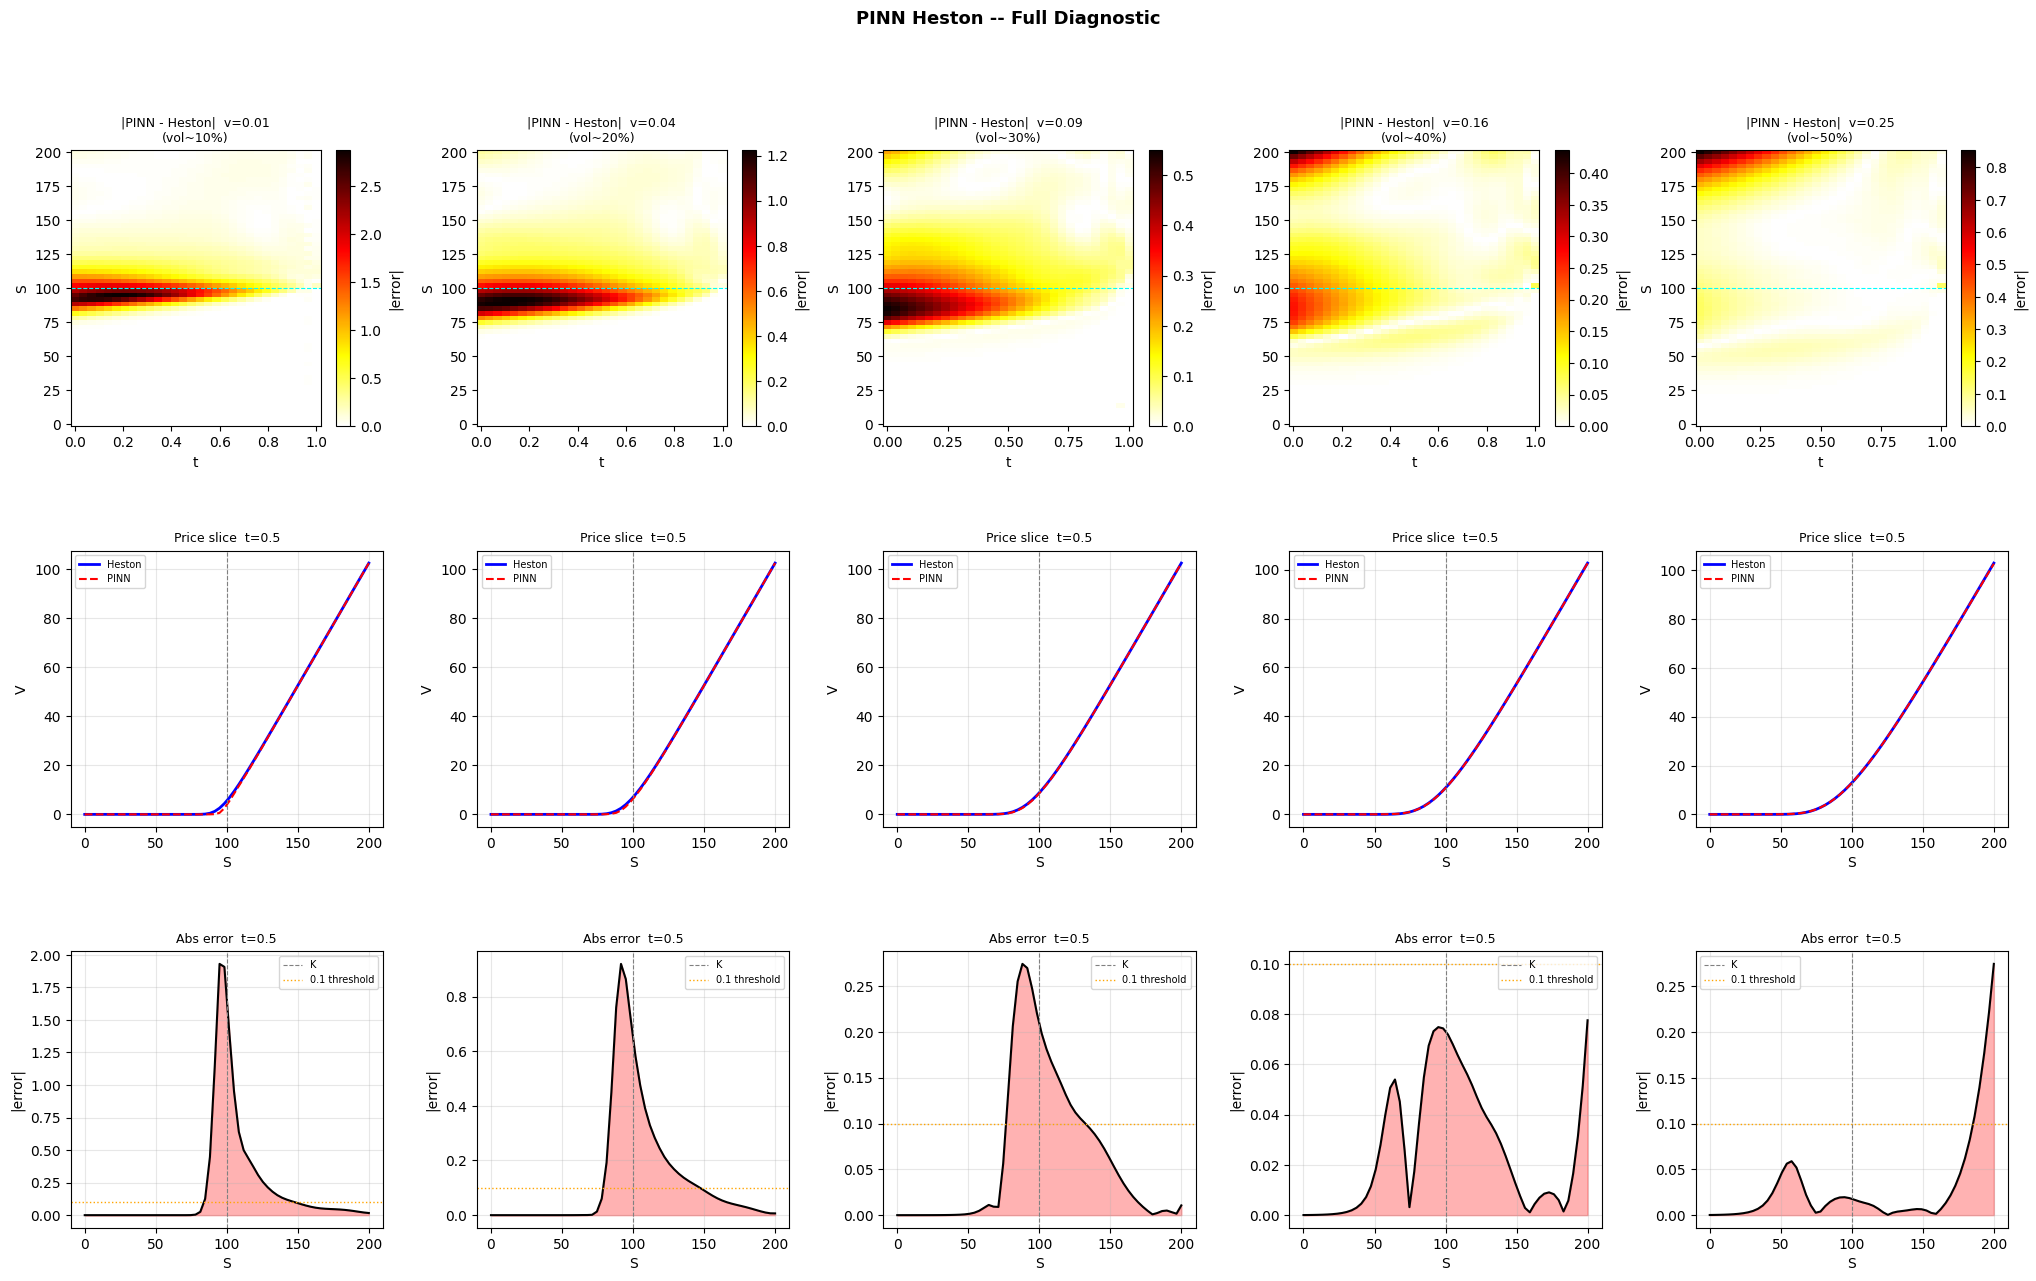

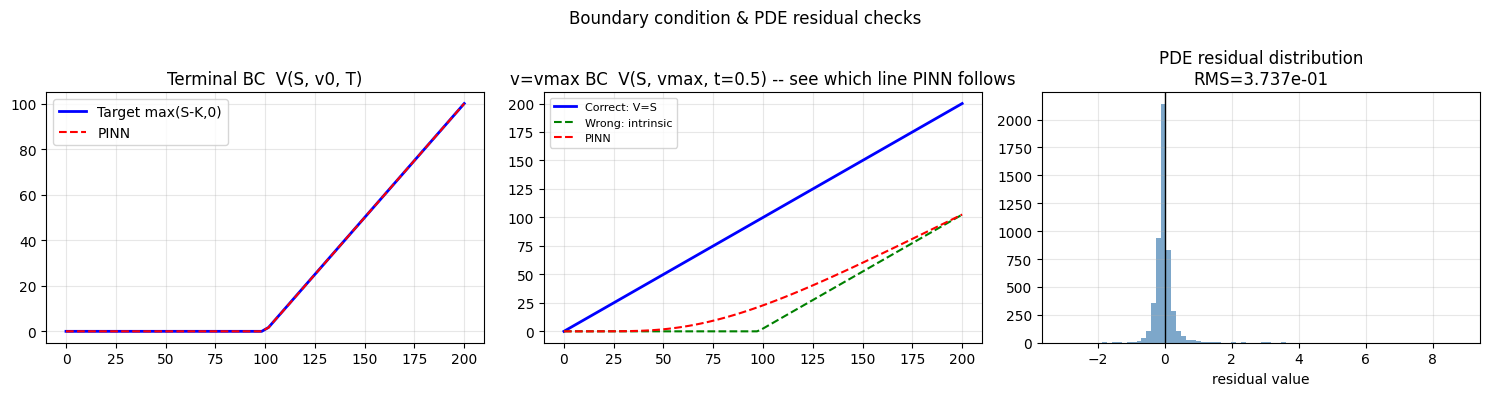

In [7]:
model_eval.eval()

nS, nT = 60, 30
S_grid = np.linspace(S_min + 1e-3, S_max, nS)
t_grid = np.linspace(t_min, t_max, nT)
v_levels_diag = [0.01, 0.04, 0.09, 0.16, 0.25]

print("=" * 65)
print("1. BOUNDARY CONDITION CHECKS")
print("=" * 65)

with torch.no_grad():

    S_T  = torch.linspace(S_min + 1e-3, S_max, 200, device=device).unsqueeze(1)
    v_T  = torch.full_like(S_T, v0)
    t_T  = torch.full_like(S_T, T)
    V_T  = model_eval(S_T, v_T, t_T).cpu().numpy().flatten()
    tgt_T = np.maximum(S_T.cpu().numpy().flatten() - K, 0.0)
    terminal_rmse = np.sqrt(np.mean((V_T - tgt_T)**2))
    terminal_max  = np.max(np.abs(V_T - tgt_T))
    print(f"  Terminal BC  RMSE: {terminal_rmse:.4e}  |  Max: {terminal_max:.4e}  (target < 1e-2)")

    t_b0 = torch.linspace(t_min, t_max, 100, device=device).unsqueeze(1)
    S_b0 = torch.zeros_like(t_b0)
    v_b0 = torch.full_like(t_b0, v0)
    V_b0 = model_eval(S_b0, v_b0, t_b0).cpu().numpy().flatten()
    s0_rmse = np.sqrt(np.mean(V_b0**2))
    s0_max  = np.max(np.abs(V_b0))
    print(f"  S=0 BC       RMSE: {s0_rmse:.4e}  |  Max: {s0_max:.4e}  (target < 1e-3)")

    t_b1  = torch.linspace(t_min, t_max, 100, device=device).unsqueeze(1)
    S_b1  = torch.full_like(t_b1, S_max)
    v_b1  = torch.full_like(t_b1, v0)
    V_b1  = model_eval(S_b1, v_b1, t_b1).cpu().numpy().flatten()
    tgt_b1 = S_max - K * np.exp(-r * (T - t_b1.cpu().numpy().flatten()))
    smax_rmse = np.sqrt(np.mean((V_b1 - tgt_b1)**2))
    smax_max  = np.max(np.abs(V_b1 - tgt_b1))
    print(f"  S=Smax BC    RMSE: {smax_rmse:.4e}  |  Max: {smax_max:.4e}  (target < 1e-1)")

    S_bv0 = torch.linspace(S_min + 1e-3, S_max, 100, device=device).unsqueeze(1)
    v_bv0 = torch.zeros_like(S_bv0)
    t_bv0 = torch.full_like(S_bv0, 0.5)
    V_bv0 = model_eval(S_bv0, v_bv0, t_bv0).cpu().numpy().flatten()
    tgt_bv0 = np.maximum(
        S_bv0.cpu().numpy().flatten() - K * np.exp(-r * (T - 0.5)), 0.0
    )
    v0bc_rmse = np.sqrt(np.mean((V_bv0 - tgt_bv0)**2))
    v0bc_max  = np.max(np.abs(V_bv0 - tgt_bv0))
    print(f"  v=0 BC       RMSE: {v0bc_rmse:.4e}  |  Max: {v0bc_max:.4e}  (target < 5e-1)")

S_bv1_rg = torch.linspace(S_min + 1e-3, S_max, 100, device=device).unsqueeze(1).requires_grad_(True)
v_bv1_rg = torch.full_like(S_bv1_rg, v_max).requires_grad_(True)
t_bv1_rg = torch.full_like(S_bv1_rg, 0.5).requires_grad_(True)
V_bv1_rg = model_eval(S_bv1_rg, v_bv1_rg, t_bv1_rg)
dV_dv_check = torch.autograd.grad(
    V_bv1_rg, v_bv1_rg,
    grad_outputs=torch.ones_like(V_bv1_rg)
)[0].detach().cpu().numpy().flatten()
neumann_rms = np.sqrt(np.mean(dV_dv_check**2))
print(f"  v=vmax Neumann dV/dv  RMS: {neumann_rms:.4e}  "
      f"{'[!] high' if neumann_rms >= 0.1 else '[ok]'}")

print("\n" + "=" * 65)
print("2. PDE RESIDUAL (interior collocation)")
print("=" * 65)

N_check = 5000
S_pde = torch.rand(N_check, 1, device=device) * (S_max - S_min) + S_min
v_pde = torch.rand(N_check, 1, device=device) * (v_max - v_min) + v_min
t_pde = torch.rand(N_check, 1, device=device) * (t_max - t_min) + t_min

res    = model_eval.heston_pde_residual(S_pde, v_pde, t_pde)
res_np = res.detach().cpu().numpy().flatten()

S_np_pde     = S_pde.detach().cpu().numpy().flatten()
atm_mask_pde = (S_np_pde >= 75) & (S_np_pde <= 125)
print(f"  Global   residual  RMS: {np.sqrt(np.mean(res_np**2)):.4e}  |  Max: {np.max(np.abs(res_np)):.4e}")
print(f"  ATM band residual  RMS: {np.sqrt(np.mean(res_np[atm_mask_pde]**2)):.4e}  (target < 1e-1)")
print(f"  OTM/ITM  residual  RMS: {np.sqrt(np.mean(res_np[~atm_mask_pde]**2)):.4e}")

print("\n" + "=" * 65)
print("3. ACCURACY vs EXACT HESTON (multiple v levels)")
print("=" * 65)

results = {}
with torch.no_grad():
    for v_lvl in v_levels_diag:
        V_exact = np.zeros((nS, nT))
        for j, t in enumerate(t_grid):
            tau = T - t
            V_exact[:, j] = heston.price_grid(S_grid, K, v_lvl, tau)

        SS, TT = np.meshgrid(S_grid, t_grid, indexing="ij")
        VV     = np.full_like(SS, v_lvl)
        S_t    = torch.tensor(SS.reshape(-1, 1), dtype=torch.float32, device=device)
        v_t    = torch.tensor(VV.reshape(-1, 1), dtype=torch.float32, device=device)
        t_t    = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
        V_pred = model_eval(S_t, v_t, t_t).cpu().numpy().reshape(nS, nT)

        abs_err    = np.abs(V_pred - V_exact)
        rel_l2     = np.linalg.norm(V_pred - V_exact) / (np.linalg.norm(V_exact) + 1e-12)
        rmse       = np.sqrt(np.mean((V_pred - V_exact)**2))
        max_err    = np.max(abs_err)

        atm_mask   = (S_grid >= 80) & (S_grid <= 120)
        rel_l2_atm = (np.linalg.norm((V_pred - V_exact)[atm_mask, :]) / (np.linalg.norm(V_exact[atm_mask, :]) + 1e-12))
        max_atm    = np.max(abs_err[atm_mask, :])

        results[v_lvl] = dict(V_exact=V_exact, V_pred=V_pred,
                               abs_err=abs_err, rel_l2=rel_l2, rmse=rmse,
                               max_err=max_err, rel_l2_atm=rel_l2_atm, max_atm=max_atm)

        flag = "[!]" if max_err > 0.3 else "[ok]"
        print(f"  {flag} v={v_lvl:.2f} (vol={math.sqrt(v_lvl):.0%})  "
              f"RelL2={rel_l2:.3e}  RelL2_ATM={rel_l2_atm:.3e}  "
              f"RMSE={rmse:.3e}  MaxErr={max_err:.3e}")

print("\n  Targets:  RelL2 < 1e-2  |  RelL2_ATM < 5e-2  |  MaxErr < 2e-1")

n_v = len(v_levels_diag)
fig = plt.figure(figsize=(5 * n_v, 14))
gs  = gridspec.GridSpec(3, n_v, figure=fig, hspace=0.45, wspace=0.3)

for col, v_lvl in enumerate(v_levels_diag):
    r_  = results[v_lvl]
    vol = math.sqrt(v_lvl)

    ax0 = fig.add_subplot(gs[0, col])
    im  = ax0.pcolormesh(t_grid, S_grid, r_["abs_err"], cmap="hot_r", vmin=0)
    plt.colorbar(im, ax=ax0, label="|error|")
    ax0.axhline(K, color="cyan", lw=0.8, ls="--", label="K")
    ax0.set_title(f"|PINN - Heston|  v={v_lvl}\n(vol~{vol:.0%})", fontsize=9)
    ax0.set_xlabel("t"); ax0.set_ylabel("S")

    ax1 = fig.add_subplot(gs[1, col])
    t_idx = np.argmin(np.abs(t_grid - 0.5))
    ax1.plot(S_grid, r_["V_exact"][:, t_idx], "b-", lw=2, label="Heston")
    ax1.plot(S_grid, r_["V_pred"][:, t_idx],  "r--", lw=1.5, label="PINN")
    ax1.axvline(K, color="gray", ls="--", lw=0.8)
    ax1.set_title(f"Price slice  t=0.5", fontsize=9)
    ax1.set_xlabel("S"); ax1.set_ylabel("V"); ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[2, col])
    ax2.plot(S_grid, r_["abs_err"][:, t_idx], "k-", lw=1.5)
    ax2.axvline(K, color="gray", ls="--", lw=0.8, label="K")
    ax2.fill_between(S_grid, r_["abs_err"][:, t_idx], alpha=0.3, color="red")
    ax2.axhline(0.1, color="orange", ls=":", lw=1, label="0.1 threshold")
    ax2.set_title(f"Abs error  t=0.5", fontsize=9)
    ax2.set_xlabel("S"); ax2.set_ylabel("|error|"); ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

fig.suptitle("PINN Heston -- Full Diagnostic", fontsize=13, fontweight="bold")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

axes2[0].plot(S_grid, np.maximum(S_grid - K, 0), "b-", lw=2, label="Target max(S-K,0)")
with torch.no_grad():
    S_t2 = torch.tensor(S_grid[:, None], dtype=torch.float32, device=device)
    v_t2 = torch.full_like(S_t2, v0)
    t_t2 = torch.full_like(S_t2, T)
    V_T2 = model_eval(S_t2, v_t2, t_t2).cpu().numpy().flatten()
axes2[0].plot(S_grid, V_T2, "r--", lw=1.5, label="PINN")
axes2[0].set_title("Terminal BC  V(S, v0, T)"); axes2[0].legend(); axes2[0].grid(alpha=0.3)

S_arr = np.linspace(S_min + 1e-3, S_max, 100)
with torch.no_grad():
    S_t3 = torch.tensor(S_arr[:, None], dtype=torch.float32, device=device)
    v_t3 = torch.full_like(S_t3, v_max)
    t_t3 = torch.full_like(S_t3, 0.5)
    V_vmax = model_eval(S_t3, v_t3, t_t3).cpu().numpy().flatten()
axes2[1].plot(S_arr, S_arr,                                               "b-",  lw=2,   label="Correct: V=S")
axes2[1].plot(S_arr, np.maximum(S_arr - K * np.exp(-r * 0.5), 0),         "g--", lw=1.5, label="Wrong: intrinsic")
axes2[1].plot(S_arr, V_vmax,                                              "r--", lw=1.5, label="PINN")
axes2[1].set_title("v=vmax BC  V(S, vmax, t=0.5) -- see which line PINN follows")
axes2[1].legend(fontsize=8); axes2[1].grid(alpha=0.3)

axes2[2].hist(res_np, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
axes2[2].axvline(0, color="black", lw=1)
axes2[2].set_title(f"PDE residual distribution\nRMS={np.sqrt(np.mean(res_np**2)):.3e}")
axes2[2].set_xlabel("residual value"); axes2[2].grid(alpha=0.3)

fig2.suptitle("Boundary condition & PDE residual checks", fontsize=12)
plt.tight_layout(); plt.show()

## Evaluation

Vectorised reference pricing with `HestonPricer.price_grid` — the whole S grid is priced in one call per maturity slice, which is much faster than the old per-point `scipy.quad` loop.


In [8]:
model_eval.eval()

nS = 40
nT = 20

S_grid_np = np.linspace(S_min + 1e-3, S_max, nS)
t_grid_np = np.linspace(t_min, t_max, nT)

print("Computing Heston reference prices (vectorised)...")
V_exact_np = np.zeros((nS, nT))
for j, t in enumerate(t_grid_np):
    tau = T - t
    V_exact_np[:, j] = heston.price_grid(S_grid_np, K, v0, tau)

SS_np, TT_np = np.meshgrid(S_grid_np, t_grid_np, indexing="ij")
VV_np        = np.full_like(SS_np, v0)

S_test = torch.tensor(SS_np.reshape(-1, 1), dtype=torch.float32, device=device)
v_test = torch.tensor(VV_np.reshape(-1, 1), dtype=torch.float32, device=device)
t_test = torch.tensor(TT_np.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    V_pred = model_eval(S_test, v_test, t_test).cpu().numpy().reshape(nS, nT)

abs_error = np.abs(V_pred - V_exact_np)
rel_l2    = np.linalg.norm(V_pred - V_exact_np) / (np.linalg.norm(V_exact_np) + 1e-12)
rmse      = np.sqrt(np.mean((V_pred - V_exact_np)**2))
max_err   = np.max(abs_error)

atm_mask      = (S_grid_np >= 80) & (S_grid_np <= 120)
rel_l2_atm    = (np.linalg.norm(V_pred[atm_mask, :] - V_exact_np[atm_mask, :])
                 / (np.linalg.norm(V_exact_np[atm_mask, :]) + 1e-12))
max_err_atm   = np.max(abs_error[atm_mask, :])

print(f"\nEvaluation at v = {v0}  (vol = {math.sqrt(v0):.2%}):")
print(f"  Rel L2 error (global)  : {rel_l2:.6e}")
print(f"  Rel L2 error (ATM band): {rel_l2_atm:.6e}")
print(f"  RMSE                   : {rmse:.6e}")
print(f"  Max abs error (global) : {max_err:.6e}")
print(f"  Max abs error (ATM)    : {max_err_atm:.6e}")


Computing Heston reference prices (vectorised)...

Evaluation at v = 0.04  (vol = 20.00%):
  Rel L2 error (global)  : 6.110979e-03
  Rel L2 error (ATM band): 5.118353e-02
  RMSE                   : 2.659297e-01
  Max abs error (global) : 1.209849e+00
  Max abs error (ATM)    : 1.209849e+00


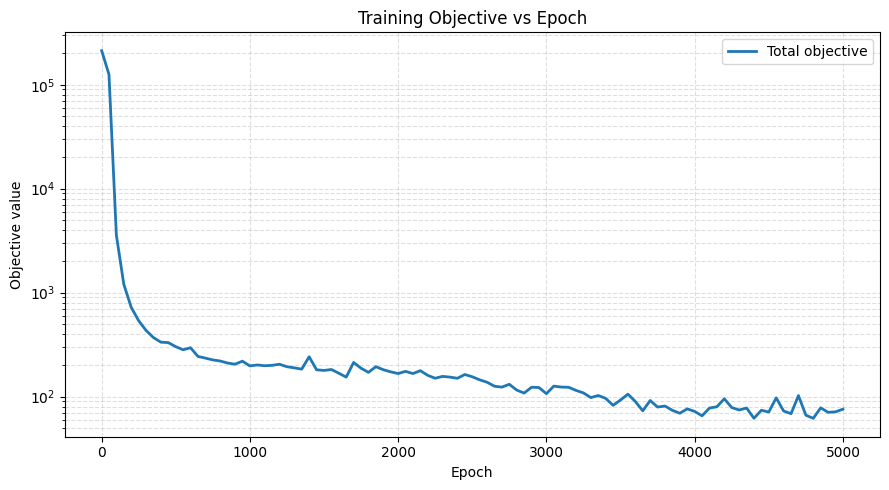

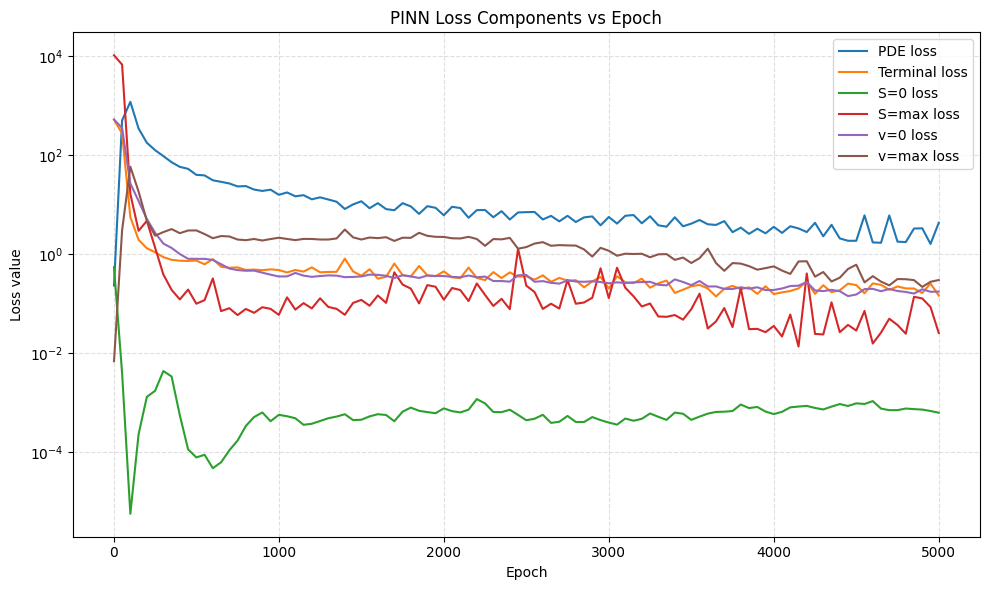


Final training objective:
  Total objective : 7.567706e+01
  PDE loss        : 4.301632e+00
  Terminal loss   : 1.457137e-01
  S=0 loss        : 6.300421e-04
  S=max loss      : 2.563932e-02
  v=0 loss        : 1.757800e-01
  v=max loss      : 3.006370e-01


In [9]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["total_loss"],
    linewidth=2,
    label="Total objective",
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Training Objective vs Epoch")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["pde_loss"], label="PDE loss")
plt.plot(history_df["epoch"], history_df["terminal_loss"], label="Terminal loss")
plt.plot(history_df["epoch"], history_df["S0_loss"], label="S=0 loss")
plt.plot(history_df["epoch"], history_df["Smax_loss"], label="S=max loss")
plt.plot(history_df["epoch"], history_df["v0_loss"], label="v=0 loss")
plt.plot(history_df["epoch"], history_df["vmax_loss"], label="v=max loss")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("PINN Loss Components vs Epoch")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal training objective:")
print(f"  Total objective : {history_df['total_loss'].iloc[-1]:.6e}")
print(f"  PDE loss        : {history_df['pde_loss'].iloc[-1]:.6e}")
print(f"  Terminal loss   : {history_df['terminal_loss'].iloc[-1]:.6e}")
print(f"  S=0 loss        : {history_df['S0_loss'].iloc[-1]:.6e}")
print(f"  S=max loss      : {history_df['Smax_loss'].iloc[-1]:.6e}")
print(f"  v=0 loss        : {history_df['v0_loss'].iloc[-1]:.6e}")
print(f"  v=max loss      : {history_df['vmax_loss'].iloc[-1]:.6e}")

## Pointwise Comparison Table


In [10]:
def compare_prices_table(model, heston, S_list, v0, T, K, t_value=0.5):
    model_eval.eval()
    tau = T - t_value
    with torch.no_grad():
        S_t = torch.tensor([[float(s)] for s in S_list], dtype=torch.float32, device=device)
        v_t = torch.full_like(S_t, float(v0))
        t_t = torch.full_like(S_t, float(t_value))
        pinn_p = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()

    exact_p  = heston.price_grid(np.array(S_list, dtype=float), K, v0, tau)
    abs_err  = np.abs(pinn_p - exact_p)
    rel_err  = abs_err / np.maximum(np.abs(exact_p), 0.1)

    return pd.DataFrame({
        "S": S_list, "t": t_value, "v": v0,
        "PINN_price": pinn_p, "Exact_Heston": exact_p,
        "Abs_error": abs_err, "Rel_error_%": rel_err * 100,
    })

S_values   = [40, 60, 80, 90, 100, 110, 120, 140, 160, 180]
df_compare = compare_prices_table(model, heston, S_values, v0, T, K, t_value=0.5)

atm_rows    = df_compare[df_compare.S.between(80, 120)]
rel_l2_full = (np.linalg.norm(df_compare.PINN_price - df_compare.Exact_Heston)
               / (np.linalg.norm(df_compare.Exact_Heston) + 1e-12))
rel_l2_atm  = (np.linalg.norm(atm_rows.PINN_price - atm_rows.Exact_Heston)
               / (np.linalg.norm(atm_rows.Exact_Heston) + 1e-12))

print(f"{'='*55}")
print(f" t=0.5, v={v0}  (vol={math.sqrt(v0):.2%})")
print(f"{'='*55}")
print(f" Rel L2 (full slice)  : {rel_l2_full:.6e}")
print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
print(f" Max rel error        : {df_compare['Rel_error_%'].max():.4f}%")
df_compare.round(6)


 t=0.5, v=0.04  (vol=20.00%)
 Rel L2 (full slice)  : 9.937324e-03
 Rel L2 (ATM [80,120]): 4.021238e-02
 Max rel error        : 73.5653%


,S,t,v,PINN_price,Exact_Heston,Abs_error,Rel_error_%
0,40,0.5,0.04,0.000005,0.000000,0.000005,0.005275
1,60,0.5,0.04,0.000159,0.000004,0.000155,0.154886
2,80,0.5,0.04,0.039990,0.151279,0.111289,73.565293
3,90,0.5,0.04,1.009592,1.855416,0.845824,45.586750
4,100,0.5,0.04,6.209186,6.837200,0.628014,9.185248
5,110,0.5,0.04,14.059520,14.410045,0.350525,2.432507
6,120,0.5,0.04,23.101463,23.329489,0.228026,0.977415
7,140,0.5,0.04,42.527401,42.648469,0.121068,0.283874
8,160,0.5,0.04,62.449684,62.510866,0.061182,0.097873
9,180,0.5,0.04,82.447868,82.479953,0.032077,0.038891


## Plots


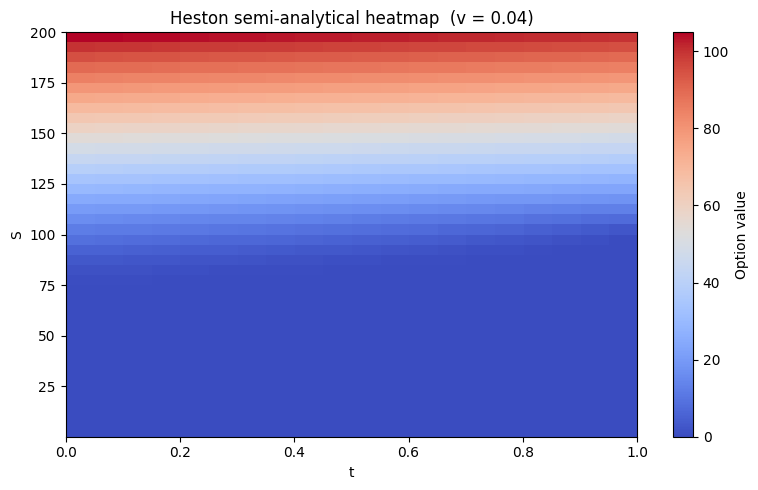


 t=0.25, v=0.04  (tau=0.750)
 Rel L2 (full slice)  : 8.191794e-03
 Rel L2 (ATM [80,120]): 6.250933e-02
 RMSE                 : 3.604331e-01
 Max abs error        : 1.194724e+00
 Max rel error        : 74.9120%


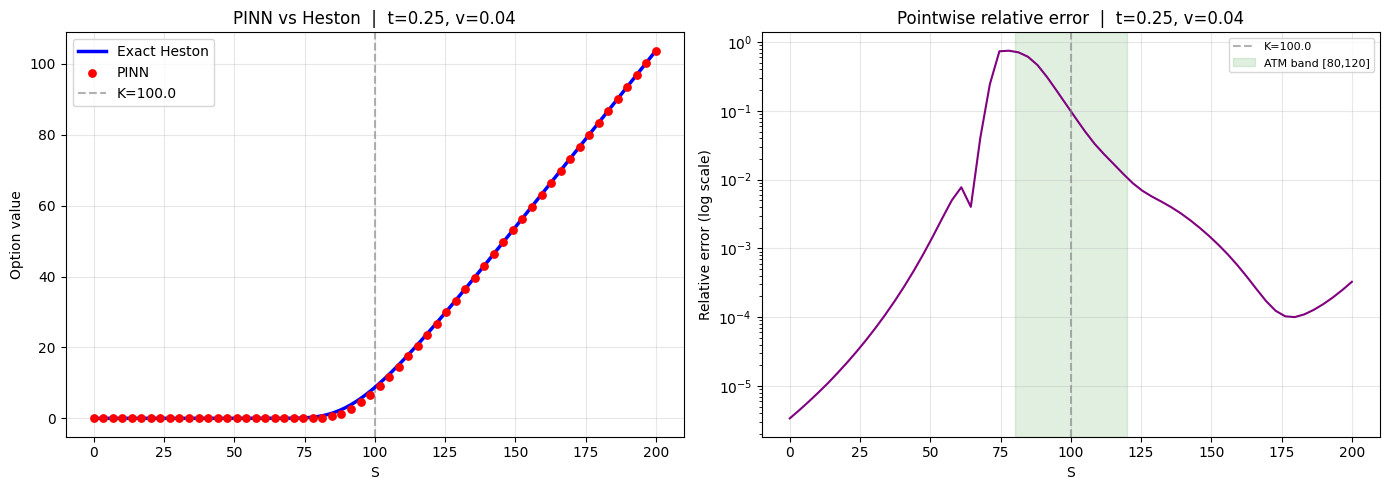


 t=0.5, v=0.04  (tau=0.500)
 Rel L2 (full slice)  : 5.875731e-03
 Rel L2 (ATM [80,120]): 4.908801e-02
 RMSE                 : 2.535010e-01
 Max abs error        : 8.911021e-01
 Max rel error        : 73.5181%


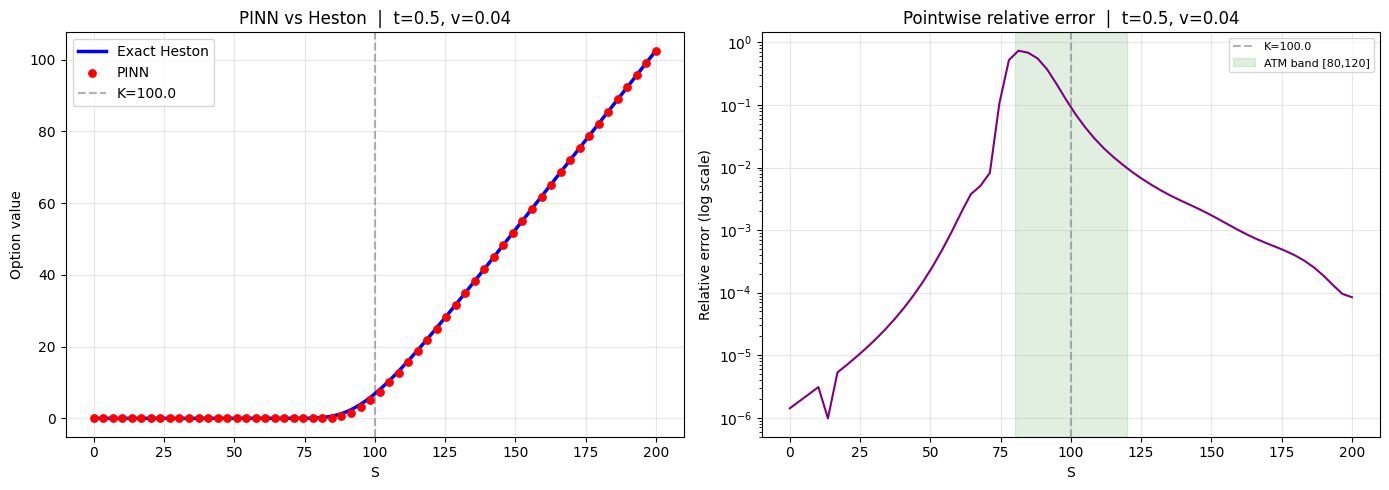


 t=0.75, v=0.04  (tau=0.250)
 Rel L2 (full slice)  : 2.871143e-03
 Rel L2 (ATM [80,120]): 2.699158e-02
 RMSE                 : 1.214751e-01
 Max abs error        : 4.319320e-01
 Max rel error        : 54.9040%


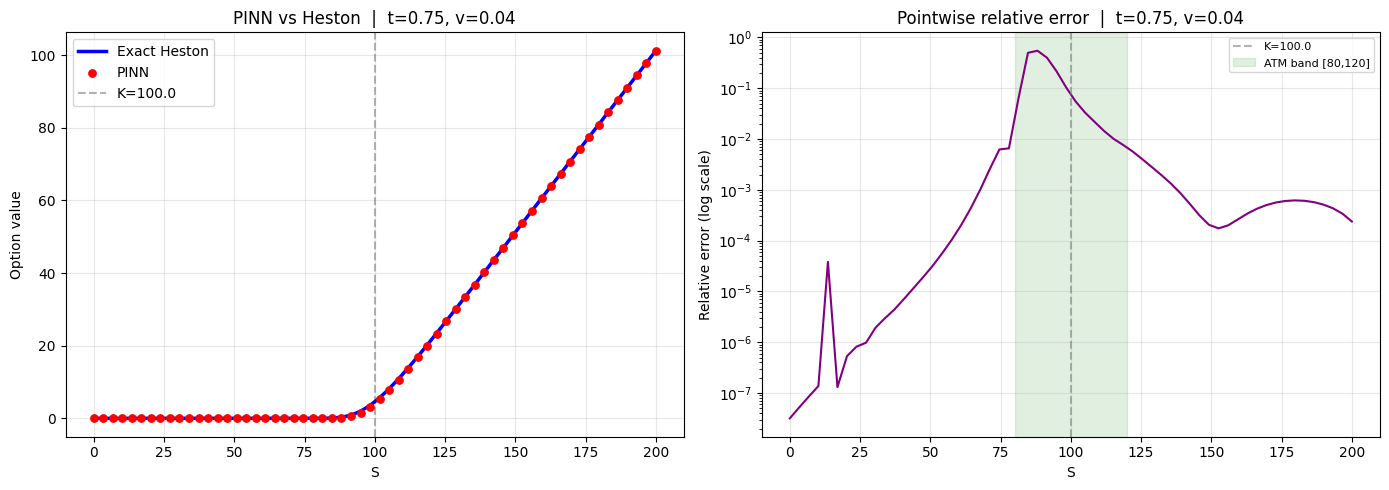

In [11]:
def plot_heston_heatmap(heston, v0, T, K, S_min, S_max, t_min, t_max, nS=40, nT=20):
    S_vals = np.linspace(S_min + 1e-3, S_max, nS)
    t_vals = np.linspace(t_min, t_max, nT)
    V_heston = np.zeros((nS, nT))
    for j, t in enumerate(t_vals):
        V_heston[:, j] = heston.price_grid(S_vals, K, v0, T - t)
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V_heston, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="coolwarm")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Heston semi-analytical heatmap  (v = {v0})")
    plt.colorbar(im, label="Option value"); plt.tight_layout(); plt.show()


def plot_single_slice(model, heston, v0, T, K, S_min, S_max, t_value=0.5,
                      nS_line=200, nS_scatter=60):
    model_eval.eval()
    tau          = T - t_value
    S_line_np    = np.linspace(S_min + 1e-3, S_max, nS_line)
    S_scatter_np = np.linspace(S_min + 1e-3, S_max, nS_scatter)

    V_heston_line    = heston.price_grid(S_line_np,    K, v0, tau)
    V_heston_scatter = heston.price_grid(S_scatter_np, K, v0, tau)

    S_t = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=torch.float32, device=device)
    v_t = torch.full_like(S_t, float(v0))
    t_t = torch.full_like(S_t, float(t_value))
    with torch.no_grad():
        V_pinn = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()

    abs_err = np.abs(V_pinn - V_heston_scatter)
    rel_err = abs_err / np.maximum(np.abs(V_heston_scatter), 0.1)
    atm_mask = (S_scatter_np >= 80) & (S_scatter_np <= 120)
    rel_l2_slice = np.linalg.norm(V_pinn - V_heston_scatter) / (np.linalg.norm(V_heston_scatter) + 1e-12)
    rel_l2_atm   = (np.linalg.norm(V_pinn[atm_mask] - V_heston_scatter[atm_mask])
                    / (np.linalg.norm(V_heston_scatter[atm_mask]) + 1e-12))

    print(f"\n{'='*55}")
    print(f" t={t_value}, v={v0}  (tau={tau:.3f})")
    print(f"{'='*55}")
    print(f" Rel L2 (full slice)  : {rel_l2_slice:.6e}")
    print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f" RMSE                 : {np.sqrt(np.mean((V_pinn - V_heston_scatter)**2)):.6e}")
    print(f" Max abs error        : {np.max(abs_err):.6e}")
    print(f" Max rel error        : {np.max(rel_err):.4%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(S_line_np, V_heston_line, color="blue", lw=2.5, label="Exact Heston", zorder=3)
    ax.scatter(S_scatter_np, V_pinn, color="red", s=28, label="PINN", zorder=4)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.set_xlabel("S"); ax.set_ylabel("Option value")
    ax.set_title(f"PINN vs Heston  |  t={t_value}, v={v0}")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(S_scatter_np, rel_err, color="purple", lw=1.5)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.axvspan(80, 120, alpha=0.12, color="green", label="ATM band [80,120]")
    ax.set_xlabel("S"); ax.set_ylabel("Relative error (log scale)")
    ax.set_title(f"Pointwise relative error  |  t={t_value}, v={v0}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


plot_heston_heatmap(heston, v0, T, K, S_min, S_max, t_min, t_max)
for t_val in [0.25, 0.5, 0.75]:
    plot_single_slice(model_eval, heston, v0, T, K, S_min, S_max, t_value=t_val)


### Error Heatmap


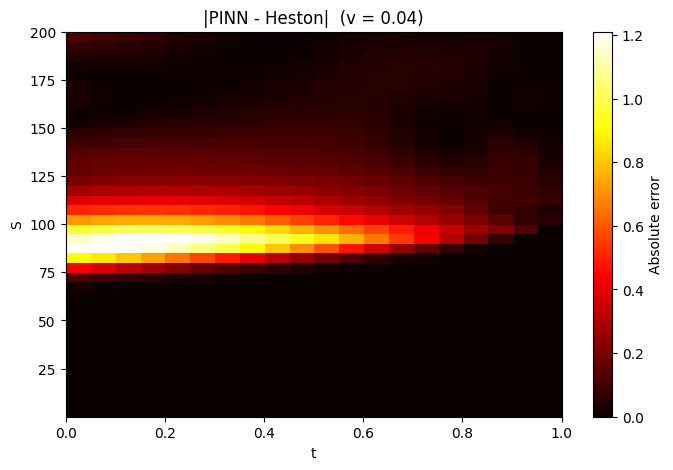

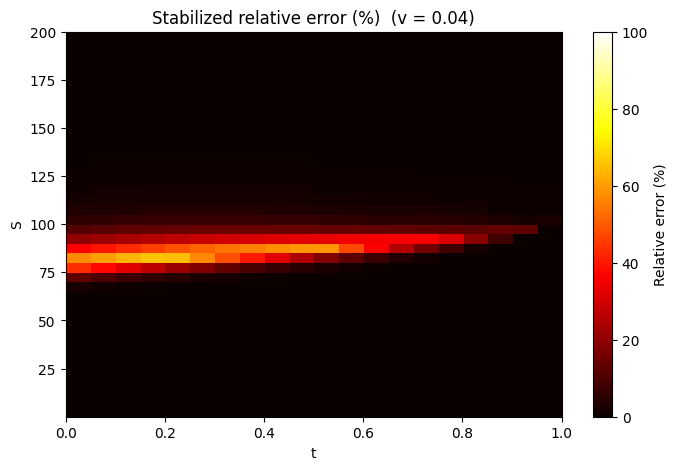

In [12]:
def plot_error_heatmap(model, heston, v0, T, K, S_min, S_max, t_min, t_max, nS=40, nT=20):
    model.eval()
    S_vals = np.linspace(S_min + 1e-3, S_max, nS)
    t_vals = np.linspace(t_min, t_max, nT)

    V_heston = np.zeros((nS, nT))
    for j, t in enumerate(t_vals):
        V_heston[:, j] = heston.price_grid(S_vals, K, v0, T - t)

    SS_np, TT_np = np.meshgrid(S_vals, t_vals, indexing="ij")
    S_t = torch.tensor(SS_np.reshape(-1, 1), dtype=torch.float32, device=device)
    v_t = torch.full_like(S_t, float(v0))
    t_t = torch.tensor(TT_np.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        V_pinn = model(S_t, v_t, t_t).cpu().numpy().reshape(nS, nT)

    abs_err = np.abs(V_pinn - V_heston)

    price_floor = 1.0
    rel_err = abs_err / np.maximum(np.abs(V_heston), price_floor) * 100

    plt.figure(figsize=(8, 5))
    im = plt.imshow(abs_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="hot")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"|PINN - Heston|  (v = {v0})")
    plt.colorbar(im, label="Absolute error")
    plt.show()

    plt.figure(figsize=(8, 5))
    im = plt.imshow(rel_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="hot", vmin=0, vmax=100)
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Stabilized relative error (%)  (v = {v0})")
    plt.colorbar(im, label="Relative error (%)")
    plt.show()

plot_error_heatmap(model_eval, heston, v0, T, K, S_min, S_max, t_min, t_max)

### PINN across variance levels

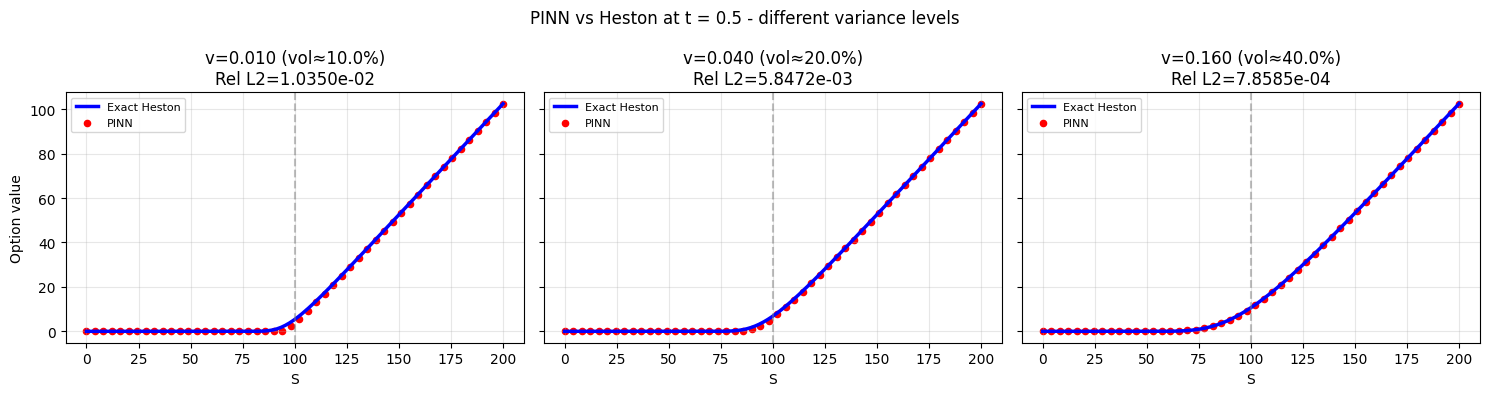

In [13]:
def plot_pinn_vs_heston_multiple_v(model, heston, v_levels, T, K, S_min, S_max, t_value=0.5):
    model_eval.eval()
    tau = T - t_value
    S_line_np    = np.linspace(S_min + 1e-3, S_max, 200)
    S_scatter_np = np.linspace(S_min + 1e-3, S_max, 50)
    fig, axes = plt.subplots(1, len(v_levels), figsize=(5 * len(v_levels), 4), sharey=True)
    if len(v_levels) == 1:
        axes = [axes]
    for ax, v_lvl in zip(axes, v_levels):
        V_hl = heston.price_grid(S_line_np,    K, v_lvl, tau)
        V_hs = heston.price_grid(S_scatter_np, K, v_lvl, tau)
        S_t  = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=torch.float32, device=device)
        v_t  = torch.full_like(S_t, float(v_lvl))
        t_t  = torch.full_like(S_t, float(t_value))
        with torch.no_grad():
            V_pinn = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()
        rel_l2 = np.linalg.norm(V_pinn - V_hs) / (np.linalg.norm(V_hs) + 1e-12)
        ax.plot(S_line_np, V_hl, color="blue", lw=2.5, label="Exact Heston")
        ax.scatter(S_scatter_np, V_pinn, color="red", s=20, label="PINN")
        ax.axvline(K, color="gray", ls="--", alpha=0.5)
        ax.set_title(f"v={v_lvl:.3f} (vol≈{math.sqrt(v_lvl):.1%})\nRel L2={rel_l2:.4e}")
        ax.set_xlabel("S"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    axes[0].set_ylabel("Option value")
    fig.suptitle(f"PINN vs Heston at t = {t_value} - different variance levels", fontsize=12)
    plt.tight_layout(); plt.show()

plot_pinn_vs_heston_multiple_v(model_eval, heston, v_levels=[0.01, 0.04, 0.16], T=T, K=K, S_min=S_min, S_max=S_max, t_value=0.5)


### Implied volatility curve: PINN prices vs true Heston prices

Implied volatility comparison
t = 0.0, tau = 1.0
Valid IV points: 81 / 81
IV RMSE    : 2.343902e-02
Max IV err : 4.298554e-02
IV RMSE in vol points: 2.3439%


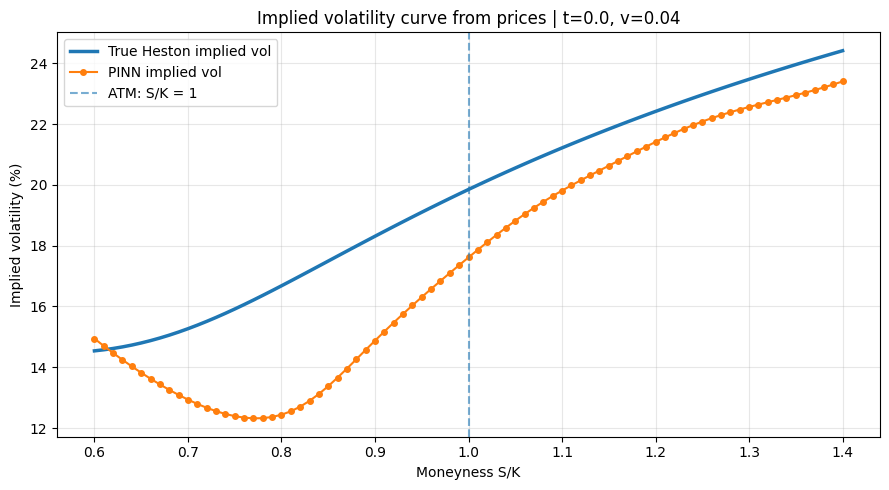

,S,Moneyness S/K,PINN price,True Heston price,PINN IV (%),True Heston IV (%),IV error (%)
0,60.0,0.60,0.003192,0.002274,14.943668,14.540375,0.403292
1,61.0,0.61,0.003952,0.003567,14.702668,14.575646,0.127021
2,62.0,0.62,0.004908,0.005509,14.469744,14.619132,-0.149388
3,63.0,0.63,0.006117,0.008381,14.245083,14.670990,-0.425907
4,64.0,0.64,0.007648,0.012557,14.028977,14.731324,-0.702348
...,...,...,...,...,...,...,...
76,136.0,1.36,41.554794,41.699616,23.032156,24.050316,-1.018160
77,137.0,1.37,42.519669,42.660462,23.117387,24.142604,-1.025216
78,138.0,1.38,43.487198,43.623347,23.207211,24.233866,-1.026655
79,139.0,1.39,44.457298,44.588156,23.302527,24.324121,-1.021594


In [14]:
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call_price(S, K, r, tau, vol):
    """Black-Scholes European call price, scalar version"""
    S = float(S)
    K = float(K)
    tau = float(tau)
    vol = float(vol)

    if tau <= 1e-12:
        return max(S - K, 0.0)

    if vol <= 1e-12:
        return max(S - K * math.exp(-r * tau), 0.0)

    d1 = (math.log(S / K) + (r + 0.5 * vol**2) * tau) / (vol * math.sqrt(tau))
    d2 = d1 - vol * math.sqrt(tau)

    return S * norm_cdf(d1) - K * math.exp(-r * tau) * norm_cdf(d2)


def implied_vol_call(price, S, K, r, tau, vol_low=1e-8, vol_high=5.0, tol=1e-8, max_iter=100):
    """
    Implied volatility by bisection
    Returns NaN if the price is outside no-arbitrage bounds
    """
    price = float(price)
    S = float(S)

    if tau <= 1e-12:
        return np.nan

    intrinsic = max(S - K * math.exp(-r * tau), 0.0)
    upper = S

    # If PINN price is slightly outside bounds, avoid crashing
    if price < intrinsic - 1e-6 or price > upper + 1e-6:
        return np.nan

    price = min(max(price, intrinsic), upper)

    if abs(price - intrinsic) < 1e-8:
        return 0.0

    low, high = vol_low, vol_high

    f_low = bs_call_price(S, K, r, tau, low) - price
    f_high = bs_call_price(S, K, r, tau, high) - price

    if f_low * f_high > 0:
        return np.nan

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = bs_call_price(S, K, r, tau, mid) - price

        if abs(f_mid) < tol:
            return mid

        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


# We plot the implied volatility curve at initial time t=0
# with fixed strike K, varying S, i.e. as a function of moneyness S/K
t_value = 0.0
tau = T - t_value

S_iv = np.linspace(60, 140, 81)

# PINN prices
model_eval.eval()
S_t = torch.tensor(S_iv.reshape(-1, 1), dtype=torch.float32, device=device)
v_t = torch.full_like(S_t, float(v0))
t_t = torch.full_like(S_t, float(t_value))

with torch.no_grad():
    pinn_prices = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()

# True Heston prices
heston_prices = heston.price_grid(S_iv, K, v0, tau)

# Implied volatilities
iv_pinn = np.array([
    implied_vol_call(price, S, K, r, tau)
    for price, S in zip(pinn_prices, S_iv)
])

iv_heston = np.array([
    implied_vol_call(price, S, K, r, tau)
    for price, S in zip(heston_prices, S_iv)
])

# Metrics on valid points only
valid = ~np.isnan(iv_pinn) & ~np.isnan(iv_heston)

iv_rmse = np.sqrt(np.mean((iv_pinn[valid] - iv_heston[valid])**2))
iv_max_err = np.max(np.abs(iv_pinn[valid] - iv_heston[valid]))

print("=" * 65)
print("Implied volatility comparison")
print("=" * 65)
print(f"t = {t_value}, tau = {tau}")
print(f"Valid IV points: {valid.sum()} / {len(S_iv)}")
print(f"IV RMSE    : {iv_rmse:.6e}")
print(f"Max IV err : {iv_max_err:.6e}")
print(f"IV RMSE in vol points: {100 * iv_rmse:.4f}%")

plt.figure(figsize=(9, 5))

plt.plot(S_iv[valid] / K, 100 * iv_heston[valid], linewidth=2.5, label="True Heston implied vol")
plt.plot(S_iv[valid] / K, 100 * iv_pinn[valid], "o-", markersize=4, label="PINN implied vol")

plt.axvline(1.0, linestyle="--", alpha=0.6, label="ATM: S/K = 1")

plt.xlabel("Moneyness S/K")
plt.ylabel("Implied volatility (%)")
plt.title(f"Implied volatility curve from prices | t={t_value}, v={v0}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

df_iv = pd.DataFrame({
    "S": S_iv,
    "Moneyness S/K": S_iv / K,
    "PINN price": pinn_prices,
    "True Heston price": heston_prices,
    "PINN IV (%)": 100 * iv_pinn,
    "True Heston IV (%)": 100 * iv_heston,
    "IV error (%)": 100 * (iv_pinn - iv_heston),
})

df_iv.round(6)

## Improved PINN: Log-Space Heston Formulation

**Key insight.** The original PINN operates in raw (S, v, t) coordinates, leading to three problems:

1. **Unbalanced PDE coefficients** — the term ½v S² ∂²C/∂S² has S up to 200, so residuals at large S dominate.
2. **Poor OTM accuracy** — uniform S sampling assigns equal weight to regions where option prices differ by orders of magnitude.
3. **Single-strike limitation** — the model is hard-coded to K = 100 and cannot produce a full IV surface.

**Fix:** change variables to  ξ = log(S/K),  τ = T − t  and normalise the output  u = C/K.  The Heston PDE becomes

    u_τ = ½v u_ξξ + (r−½v) u_ξ + ρσv u_ξv + ½σ²v u_vv + κ(θ−v) u_v − r u

with clean boundary conditions that no longer involve S or K.  
Because K does not appear in the PDE, **one trained model prices options for any strike**: C(S,K,v,τ) = K · u(log(S/K), v, τ).


In [ ]:
class PINN_Heston_LogSpace(nn.Module):

    def __init__(
        self,
        r, kappa, theta, sigma, rho, T,
        xi_min, xi_max,
        v_min, v_max,
        hidden_layers,
        activation_fun=nn.SiLU,
        loss_weights=None,
        atm_sigma=0.40,
    ):
        super().__init__()
        self.r, self.kappa, self.theta = r, kappa, theta
        self.sigma, self.rho  = sigma, rho
        self.T                = T
        self.xi_min, self.xi_max = xi_min, xi_max
        self.v_min,  self.v_max  = v_min,  v_max
        self.atm_sigma        = atm_sigma
        self.mse              = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                "pde":      1.0,
                "terminal": 150.0,
                "v0":       20.0,
                "xi_lo":    5.0,
                "xi_hi":    10.0,
            }
        self.loss_weights = loss_weights

        layers = [nn.Linear(3, hidden_layers[0]), activation_fun()]
        for i in range(len(hidden_layers) - 1):
            layers += [nn.Linear(hidden_layers[i], hidden_layers[i+1]),
                       activation_fun()]
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight,
                    gain=nn.init.calculate_gain("relu"))
                nn.init.zeros_(m.bias)

    #  forward 
    def forward(self, xi, v, tau):
        xi_n  = 2*(xi  - self.xi_min)/(self.xi_max - self.xi_min) - 1
        v_n   = 2*(v   - self.v_min) /(self.v_max  - self.v_min)  - 1
        tau_n = 2*tau / self.T - 1
        return F.softplus(self.net(torch.cat([xi_n, v_n, tau_n], dim=1)))

    def call_price(self, S, K, v, tau):
        """C(S, K, v, τ) = K · u(log(S/K), v, τ)  –  works for any K."""
        xi = torch.log(torch.clamp(S / K, min=1e-12))
        return K * self.forward(xi, v, tau)

    #  log-space PDE residual 
    def _residual_core(self, xi, v, tau):
        xi  = xi.detach().requires_grad_(True)
        v   = v.detach().requires_grad_(True)
        tau = tau.detach().requires_grad_(True)

        u = self.forward(xi, v, tau)

        u_tau, u_xi, u_v = torch.autograd.grad(
            u, [tau, xi, v],
            grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True,
        )
        u_xixi, u_xiv = torch.autograd.grad(
            u_xi, [xi, v],
            grad_outputs=torch.ones_like(u_xi),
            create_graph=True, retain_graph=True,
        )
        u_vv = torch.autograd.grad(
            u_v, v,
            grad_outputs=torch.ones_like(u_v),
            create_graph=True,
        )[0]

        rhs = (0.5 * v * u_xixi
               + (self.r - 0.5 * v) * u_xi
               + self.rho * self.sigma * v * u_xiv
               + 0.5 * self.sigma**2 * v * u_vv
               + self.kappa * (self.theta - v) * u_v
               - self.r * u)
        return u_tau - rhs   # residual; must = 0

    #  sampling 
    def _sample_xi(self, N, dev):
        N_atm = N // 2
        N_uni = N - N_atm
        xi_atm = (torch.randn(N_atm, 1, device=dev) * self.atm_sigma
                  ).clamp(self.xi_min, self.xi_max)
        xi_uni = (torch.rand(N_uni, 1, device=dev)
                  * (self.xi_max - self.xi_min) + self.xi_min)
        return torch.cat([xi_atm, xi_uni])

    def sample_training_points(self, N_f, N_ter, N_b):
        dev = next(self.parameters()).device
        eps = 1e-6

        # Interior
        xi_f  = self._sample_xi(N_f, dev)
        v_f   = torch.rand(N_f, 1, device=dev) * (self.v_max - eps) + eps
        tau_f = torch.rand(N_f, 1, device=dev) * self.T

        # Terminal τ=0 — dense near kink at ξ=0
        xi_T  = (torch.randn(N_ter, 1, device=dev) * 0.60
                 ).clamp(self.xi_min, self.xi_max)
        v_T   = torch.rand(N_ter, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        tau_T = torch.zeros(N_ter, 1, device=dev)

        # v = 0 boundary
        xi_v0  = self._sample_xi(N_b, dev)
        v_v0   = torch.zeros(N_b, 1, device=dev)
        tau_v0 = torch.rand(N_b, 1, device=dev) * self.T

        # ξ = ξ_min  (deep OTM: u ≈ 0)
        xi_lo  = torch.full((N_b, 1), self.xi_min, device=dev)
        v_lo   = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        tau_lo = torch.rand(N_b, 1, device=dev) * self.T

        # ξ = ξ_max  (deep ITM: u ≈ e^ξ_max − e^{−rτ})
        xi_hi  = torch.full((N_b, 1), self.xi_max, device=dev)
        v_hi   = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        tau_hi = torch.rand(N_b, 1, device=dev) * self.T

        return (xi_f, v_f, tau_f,
                xi_T, v_T, tau_T,
                xi_v0, v_v0, tau_v0,
                xi_lo, v_lo, tau_lo,
                xi_hi, v_hi, tau_hi)

    #  loss 
    def compute_loss_from_data(self, data, pde_weight_override=None):
        (xi_f, v_f, tau_f,
         xi_T, v_T, tau_T,
         xi_v0, v_v0, tau_v0,
         xi_lo, v_lo, tau_lo,
         xi_hi, v_hi, tau_hi) = data

        res      = self._residual_core(xi_f, v_f, tau_f)
        loss_pde = self.mse(res, torch.zeros_like(res))

        u_T      = self.forward(xi_T, v_T, tau_T)
        loss_ter = self.mse(u_T, torch.clamp(torch.exp(xi_T) - 1.0, min=0.0))

        u_v0     = self.forward(xi_v0, v_v0, tau_v0)
        tgt_v0   = torch.clamp(torch.exp(xi_v0)
                               - torch.exp(-self.r * tau_v0), min=0.0)
        loss_v0  = self.mse(u_v0, tgt_v0)

        u_lo     = self.forward(xi_lo, v_lo, tau_lo)
        loss_lo  = self.mse(u_lo, torch.zeros_like(u_lo))

        u_hi     = self.forward(xi_hi, v_hi, tau_hi)
        tgt_hi   = torch.clamp(
            math.exp(self.xi_max) - torch.exp(-self.r * tau_hi),
            min=0.0)
        loss_hi  = self.mse(u_hi, tgt_hi)

        w_pde = (pde_weight_override if pde_weight_override is not None
                 else self.loss_weights["pde"])

        loss = (w_pde                           * loss_pde
                + self.loss_weights["terminal"] * loss_ter
                + self.loss_weights["v0"]       * loss_v0
                + self.loss_weights["xi_lo"]    * loss_lo
                + self.loss_weights["xi_hi"]    * loss_hi)

        return loss, {
            "loss_pde":      loss_pde.item(),
            "loss_terminal": loss_ter.item(),
            "loss_v0":       loss_v0.item(),
            "loss_xi_lo":    loss_lo.item(),
            "loss_xi_hi":    loss_hi.item(),
        }

    def compute_loss(self, N_f, N_ter, N_b, pde_weight_override=None):
        return self.compute_loss_from_data(
            self.sample_training_points(N_f, N_ter, N_b),
            pde_weight_override=pde_weight_override,
        )


In [16]:
torch.manual_seed(0)
np.random.seed(0)

# ξ domain covers S/K ∈ [e^{-2.5}, e^{1.0}] ≈ [0.082, 2.72]
xi_min_ls = -2.5
xi_max_ls =  1.0

loss_weights_ls = {
    "pde":      1.0,
    "terminal": 150.0,
    "v0":       20.0,
    "xi_lo":    5.0,
    "xi_hi":    10.0,
}

model_ls = PINN_Heston_LogSpace(
    r, kappa, theta, sigma, rho, T,
    xi_min=xi_min_ls, xi_max=xi_max_ls,
    v_min=v_min, v_max=v_max,
    hidden_layers=[128, 128, 128, 128],
    activation_fun=nn.SiLU,
    loss_weights=loss_weights_ls,
    atm_sigma=0.40,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model_ls.parameters()):,}")
print(f"ξ domain : [{xi_min_ls}, {xi_max_ls}]  →  S/K ∈ "
      f"[{math.exp(xi_min_ls):.3f}, {math.exp(xi_max_ls):.3f}]")
print(f"v domain : [{v_min}, {v_max}],  τ ∈ [0, {T}]")
print(f"Strike invariant: C(S,K,v,τ) = K · u(log(S/K), v, τ)")


Parameters: 50,177
ξ domain : [-2.5, 1.0]  →  S/K ∈ [0.082, 2.718]
v domain : [0.0, 1.0],  τ ∈ [0, 1.0]
Strike invariant: C(S,K,v,τ) = K · u(log(S/K), v, τ)


In [17]:
optimizer_ls = optim.Adam(model_ls.parameters(), lr=5e-4)
scheduler_ls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ls, mode="min", factor=0.5, patience=500)

N_f_ls, N_ter_ls, N_b_ls = 20_000, 10_000, 3_000
resample_ls = 75
epochs_ls   = 5_000

history_ls = {k: [] for k in [
    "epoch", "total_loss", "pde_loss",
    "terminal_loss", "v0_loss", "xi_lo_loss", "xi_hi_loss"]}

best_loss_ls  = float("inf")
best_state_ls = None
data_ls = model_ls.sample_training_points(N_f_ls, N_ter_ls, N_b_ls)

pbar_ls = tqdm(range(1, epochs_ls + 1), desc="Adam (log-space)",
               dynamic_ncols=True)
adam_start_ls = time.time()

for epoch in pbar_ls:
    if epoch % resample_ls == 1:
        data_ls = model_ls.sample_training_points(N_f_ls, N_ter_ls, N_b_ls)

    optimizer_ls.zero_grad(set_to_none=True)
    pde_w = 1.0 + 9.0 * min(epoch / 2_000, 1.0)
    loss, parts = model_ls.compute_loss_from_data(
        data_ls, pde_weight_override=pde_w)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_ls.parameters(), max_norm=1.0)
    optimizer_ls.step()
    scheduler_ls.step(loss.detach())

    if loss.item() < best_loss_ls:
        best_loss_ls  = loss.item()
        best_state_ls = {k: v.clone() for k, v in model_ls.state_dict().items()}

    if epoch % 50 == 0 or epoch == 1:
        history_ls["epoch"].append(epoch)
        history_ls["total_loss"].append(loss.item())
        history_ls["pde_loss"].append(parts["loss_pde"])
        history_ls["terminal_loss"].append(parts["loss_terminal"])
        history_ls["v0_loss"].append(parts["loss_v0"])
        history_ls["xi_lo_loss"].append(parts["loss_xi_lo"])
        history_ls["xi_hi_loss"].append(parts["loss_xi_hi"])

    pbar_ls.set_postfix(loss=f"{loss.item():.3e}",
                        best=f"{best_loss_ls:.3e}", pde_w=f"{pde_w:.1f}")

    if epoch % 1000 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.4e} | "
              f"PDE(w={pde_w:.1f}): {parts['loss_pde']:.3e} | "
              f"Terminal: {parts['loss_terminal']:.3e} | "
              f"v=0: {parts['loss_v0']:.3e} | "
              f"ξ_lo: {parts['loss_xi_lo']:.3e} | "
              f"ξ_hi: {parts['loss_xi_hi']:.3e}")

adam_time_ls = time.time() - adam_start_ls
print(f"\nAdam done in {adam_time_ls:.1f}s. Restoring best (loss={best_loss_ls:.4e})")
model_ls.load_state_dict(best_state_ls)

# L-BFGS fine-tuning — more iterations than original
print("\nStarting L-BFGS fine-tuning...")
lbfgs_start_ls = time.time()
fixed_data_ls = model_ls.sample_training_points(N_f_ls, N_ter_ls, N_b_ls)

opt_lbfgs_ls = torch.optim.LBFGS(
    model_ls.parameters(),
    lr=1.0, max_iter=5_000, max_eval=10_000,
    history_size=100, line_search_fn="strong_wolfe",
)

def closure_ls():
    opt_lbfgs_ls.zero_grad()
    loss, _ = model_ls.compute_loss_from_data(
        fixed_data_ls, pde_weight_override=10.0)
    loss.backward()
    return loss

opt_lbfgs_ls.step(closure_ls)
lbfgs_time_ls = time.time() - lbfgs_start_ls
print(f"L-BFGS done in {lbfgs_time_ls:.1f}s  |  "
      f"Total: {adam_time_ls + lbfgs_time_ls:.1f}s")


Adam (log-space):   0%|          | 1/5000 [00:01<1:29:09,  1.07s/it, best=7.930e+01, loss=7.930e+01, pde_w=1.0]

Epoch     1 | Total: 7.9301e+01 | PDE(w=1.0): 1.014e-04 | Terminal: 3.936e-01 | v=0: 3.632e-01 | ξ_lo: 4.550e-01 | ξ_hi: 1.073e+00


Adam (log-space):  20%|██        | 1000/5000 [10:59<39:40,  1.68it/s, best=9.712e-02, loss=1.041e-01, pde_w=5.5] 

Epoch  1000 | Total: 1.0406e-01 | PDE(w=5.5): 4.277e-03 | Terminal: 4.097e-04 | v=0: 8.749e-04 | ξ_lo: 1.540e-17 | ξ_hi: 1.585e-04


Adam (log-space):  40%|████      | 2000/5000 [21:18<36:35,  1.37it/s, best=5.823e-02, loss=7.099e-02, pde_w=10.0] 

...

Epoch  3000 | Total: 3.8924e-02 | PDE(w=10.0): 1.451e-03 | Terminal: 1.332e-04 | v=0: 1.610e-04 | ξ_lo: 5.023e-16 | ξ_hi: 1.211e-04


Adam (log-space):  80%|████████  | 4000/5000 [42:28<08:40,  1.92it/s, best=2.528e-02, loss=3.676e-02, pde_w=10.0]  

Epoch  4000 | Total: 3.6764e-02 | PDE(w=10.0): 1.059e-03 | Terminal: 1.435e-04 | v=0: 1.170e-04 | ξ_lo: 4.747e-16 | ξ_hi: 2.303e-04


Adam (log-space): 100%|██████████| 5000/5000 [52:04<00:00,  1.60it/s, best=1.769e-02, loss=2.608e-02, pde_w=10.0]


Epoch  5000 | Total: 2.6081e-02 | PDE(w=10.0): 7.121e-04 | Terminal: 1.019e-04 | v=0: 6.631e-05 | ξ_lo: 1.329e-15 | ξ_hi: 2.348e-04

Adam done in 3124.2s. Restoring best (loss=1.7690e-02)

Starting L-BFGS fine-tuning...
L-BFGS done in 2465.1s  |  Total: 5589.3s


ACCURACY vs EXACT HESTON  –  log-space model
     v     vol       RelL2     RelL2_ATM        RMSE      MaxErr
  [!] v=0.01  vol=10%  RelL2=1.178e-02  RelL2_ATM=1.032e-01  RMSE=5.091e-01  MaxErr=3.229e+00
  [!] v=0.04  vol=20%  RelL2=6.747e-03  RelL2_ATM=5.464e-02  RMSE=2.920e-01  MaxErr=1.444e+00
  [!] v=0.09  vol=30%  RelL2=3.238e-03  RelL2_ATM=2.165e-02  RMSE=1.406e-01  MaxErr=6.309e-01
  [!] v=0.16  vol=40%  RelL2=1.688e-03  RelL2_ATM=8.950e-03  RMSE=7.372e-02  MaxErr=3.061e-01
  [ok] v=0.25  vol=50%  RelL2=1.026e-03  RelL2_ATM=4.202e-03  RMSE=4.520e-02  MaxErr=1.871e-01

Target: RelL2 < 1e-2  |  RelL2_ATM < 5e-2  |  MaxErr < 2e-1

POINTWISE COMPARISON  t=0.5, v=v0=0.04
  S   PINN_LS  Exact_Heston  Abs_error  Rel_error_%
 40  0.000000        0.0000     0.0000       0.0000
 60  0.000000        0.0000     0.0000       0.0037
 80  0.000000        0.1513     0.1512      99.9773
 90  1.075300        1.8554     0.7801      42.0459
100  6.269000        6.8372     0.5682       8.3107
110 14

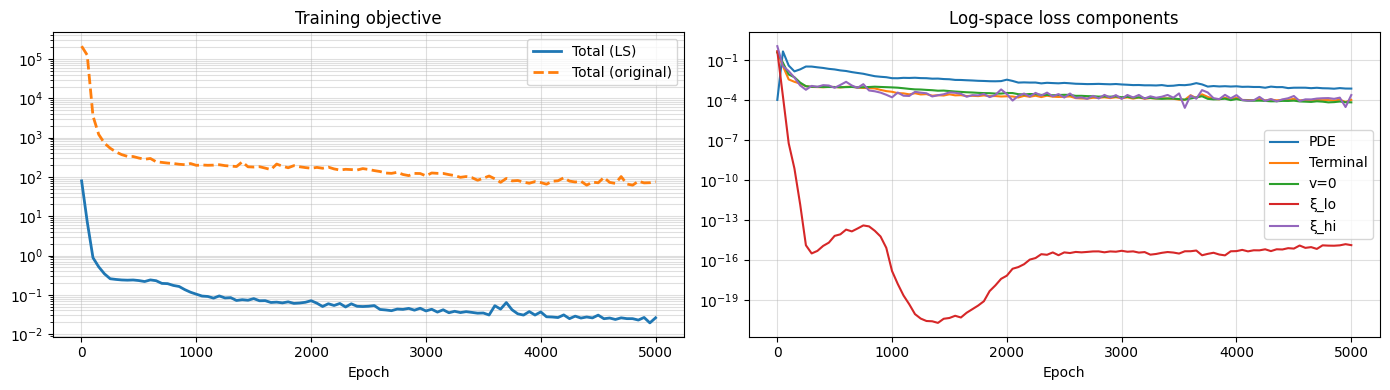

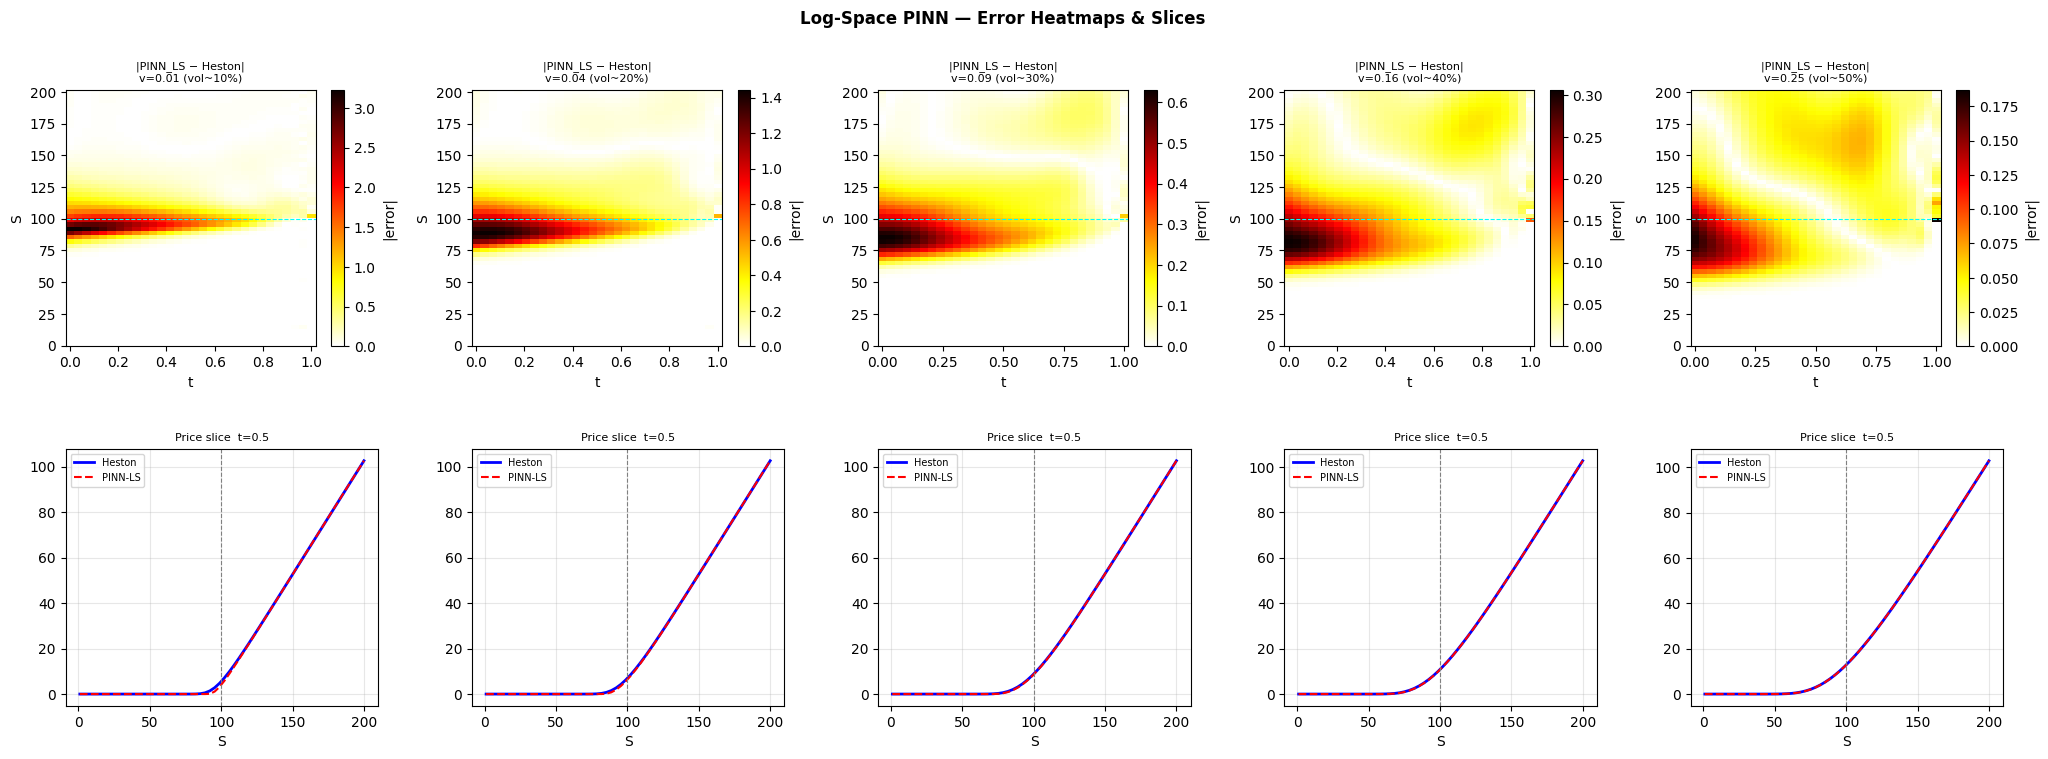

In [ ]:
model_ls.eval()

nS_ls, nT_ls = 60, 30
S_grid_ls = np.linspace(1.0, S_max, nS_ls)    # S from 1 to 200
t_grid_ls = np.linspace(t_min, t_max, nT_ls)
v_levels_eval = [0.01, 0.04, 0.09, 0.16, 0.25]

# Clip ξ=log(S/K) to model domain
xi_grid_ls = np.clip(np.log(S_grid_ls / K), xi_min_ls + 1e-4, xi_max_ls - 1e-4)

print("=" * 65)
print("ACCURACY vs EXACT HESTON  –  log-space model")
print("=" * 65)
print(f"{'v':>6}  {'vol':>6}  {'RelL2':>10}  {'RelL2_ATM':>12}  "
      f"{'RMSE':>10}  {'MaxErr':>10}")

results_ls = {}
with torch.no_grad():
    for v_lvl in v_levels_eval:
        V_exact = np.zeros((nS_ls, nT_ls))
        for j, t in enumerate(t_grid_ls):
            V_exact[:, j] = heston.price_grid(S_grid_ls, K, v_lvl, T - t)

        XI, TT = np.meshgrid(xi_grid_ls, t_grid_ls, indexing="ij")
        xi_t  = torch.tensor(XI.reshape(-1, 1), dtype=torch.float32, device=device)
        v_t   = torch.full_like(xi_t, float(v_lvl))
        tau_t = torch.tensor((T - TT).reshape(-1, 1), dtype=torch.float32, device=device)

        u_pred = model_ls(xi_t, v_t, tau_t).cpu().numpy().reshape(nS_ls, nT_ls)
        V_pred = K * u_pred

        abs_err    = np.abs(V_pred - V_exact)
        rel_l2     = np.linalg.norm(V_pred - V_exact) / (np.linalg.norm(V_exact) + 1e-12)
        rmse       = np.sqrt(np.mean((V_pred - V_exact)**2))
        max_err    = np.max(abs_err)
        atm_mask   = (S_grid_ls >= 80) & (S_grid_ls <= 120)
        rel_l2_atm = (np.linalg.norm((V_pred - V_exact)[atm_mask, :])
                      / (np.linalg.norm(V_exact[atm_mask, :]) + 1e-12))

        results_ls[v_lvl] = dict(V_exact=V_exact, V_pred=V_pred,
                                  abs_err=abs_err, rel_l2=rel_l2, rmse=rmse,
                                  max_err=max_err, rel_l2_atm=rel_l2_atm)

        flag = "[!]" if max_err > 0.3 else "[ok]"
        print(f"  {flag} v={v_lvl:.2f}  vol={math.sqrt(v_lvl):.0%}  "
              f"RelL2={rel_l2:.3e}  RelL2_ATM={rel_l2_atm:.3e}  "
              f"RMSE={rmse:.3e}  MaxErr={max_err:.3e}")

print()
print("Target: RelL2 < 1e-2  |  RelL2_ATM < 5e-2  |  MaxErr < 2e-1")

#  Pointwise comparison at t=0.5, v=v0 
print("\n" + "=" * 65)
print("POINTWISE COMPARISON  t=0.5, v=v0=0.04")
print("=" * 65)

S_pts = [40, 60, 80, 90, 100, 110, 120, 140, 160, 180]
tau_pt = T - 0.5

xi_pts = np.clip(np.log(np.array(S_pts, float) / K),
                 xi_min_ls + 1e-4, xi_max_ls - 1e-4)
with torch.no_grad():
    xi_t = torch.tensor(xi_pts.reshape(-1,1), dtype=torch.float32, device=device)
    v_t  = torch.full_like(xi_t, float(v0))
    tau_t = torch.full_like(xi_t, float(tau_pt))
    u_pred_pt = model_ls(xi_t, v_t, tau_t).cpu().numpy().flatten()

pinn_pts   = K * u_pred_pt
exact_pts  = heston.price_grid(np.array(S_pts, float), K, v0, tau_pt)
abs_err_pt = np.abs(pinn_pts - exact_pts)
rel_err_pt = abs_err_pt / np.maximum(np.abs(exact_pts), 0.1)

df_ls = pd.DataFrame({
    "S": S_pts,
    "PINN_LS": pinn_pts.round(4),
    "Exact_Heston": exact_pts.round(4),
    "Abs_error": abs_err_pt.round(4),
    "Rel_error_%": (rel_err_pt * 100).round(4),
})
print(df_ls.to_string(index=False))

#  Loss history 
hist_ls = pd.DataFrame(history_ls)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(hist_ls["epoch"], hist_ls["total_loss"], lw=2, label="Total (LS)")
axes[0].semilogy(history_df["epoch"], history_df["total_loss"], lw=2,
                 ls="--", label="Total (original)")
axes[0].set_xlabel("Epoch"); axes[0].set_title("Training objective"); axes[0].legend()
axes[0].grid(True, which="both", alpha=0.4)

for key, label in [("pde_loss", "PDE"), ("terminal_loss", "Terminal"),
                   ("v0_loss", "v=0"), ("xi_lo_loss", "ξ_lo"), ("xi_hi_loss", "ξ_hi")]:
    axes[1].semilogy(hist_ls["epoch"], hist_ls[key], lw=1.5, label=label)
axes[1].set_xlabel("Epoch"); axes[1].set_title("Log-space loss components")
axes[1].legend(); axes[1].grid(True, which="both", alpha=0.4)

plt.tight_layout(); plt.show()

#  Error heatmap 
n_v = len(v_levels_eval)
fig2, axes2 = plt.subplots(2, n_v, figsize=(5*n_v, 8),
                            gridspec_kw={"hspace": 0.4, "wspace": 0.3})

for col, v_lvl in enumerate(v_levels_eval):
    r_ = results_ls[v_lvl]
    vol = math.sqrt(v_lvl)

    ax = axes2[0, col]
    im = ax.pcolormesh(t_grid_ls, S_grid_ls, r_["abs_err"], cmap="hot_r", vmin=0)
    plt.colorbar(im, ax=ax, label="|error|")
    ax.axhline(K, color="cyan", lw=0.8, ls="--")
    ax.set_title(f"|PINN_LS − Heston|\nv={v_lvl} (vol~{vol:.0%})", fontsize=8)
    ax.set_xlabel("t"); ax.set_ylabel("S")

    ax = axes2[1, col]
    tidx = np.argmin(np.abs(t_grid_ls - 0.5))
    ax.plot(S_grid_ls, r_["V_exact"][:, tidx], "b-", lw=2, label="Heston")
    ax.plot(S_grid_ls, r_["V_pred"][:,  tidx], "r--", lw=1.5, label="PINN-LS")
    ax.axvline(K, color="gray", ls="--", lw=0.8)
    ax.set_title(f"Price slice  t=0.5", fontsize=8)
    ax.set_xlabel("S"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig2.suptitle("Log-Space PINN — Error Heatmaps & Slices", fontsize=12, fontweight="bold")
plt.show()


## Implied Volatility Surface

Because `C(S,K,v,τ) = K · u(log(S/K), v, τ)` the log-space model is **strike-invariant**: we evaluate it for any K without retraining.

Improvements over the original single-strike IV curve:
- **Newton-Raphson IV solver** — converges in ~5 iterations instead of ~100 bisection steps, and handles edge cases more gracefully.
- **Full IV surface** — multiple strikes × maturities in a single evaluation pass.
- **Side-by-side comparison** of log-space PINN vs original PINN vs exact Heston.


IV Surface – log-space PINN vs exact Heston
      K      τ   IV RMSE (%)    MaxErr (%)    Pts
  K=   80  τ=0.25  RMSE=   12.2355%  MaxErr=   21.8595%  pts= 108
  K=   90  τ=0.25  RMSE=   12.0349%  MaxErr=   21.8610%  pts= 126
  K=  100  τ=0.25  RMSE=   10.2191%  MaxErr=   21.8604%  pts= 126
  K=  110  τ=0.25  RMSE=    6.8455%  MaxErr=   18.7355%  pts= 122
  K=  120  τ=0.25  RMSE=    3.8537%  MaxErr=   11.1949%  pts= 119

  K=   80  τ=0.50  RMSE=    4.1638%  MaxErr=    9.7748%  pts= 124
  K=   90  τ=0.50  RMSE=    4.0952%  MaxErr=    9.8017%  pts= 145
  K=  100  τ=0.50  RMSE=    4.0719%  MaxErr=    9.8924%  pts= 161
  K=  110  τ=0.50  RMSE=    3.7698%  MaxErr=    9.9482%  pts= 161
  K=  120  τ=0.50  RMSE=    3.5329%  MaxErr=    9.9631%  pts= 161

  K=   80  τ=1.00  RMSE=    3.8804%  MaxErr=   10.7825%  pts= 161
  K=   90  τ=1.00  RMSE=    3.8099%  MaxErr=   10.9012%  pts= 161
  K=  100  τ=1.00  RMSE=    3.8932%  MaxErr=   10.8929%  pts= 161
  K=  110  τ=1.00  RMSE=    4.0552%  MaxErr=  

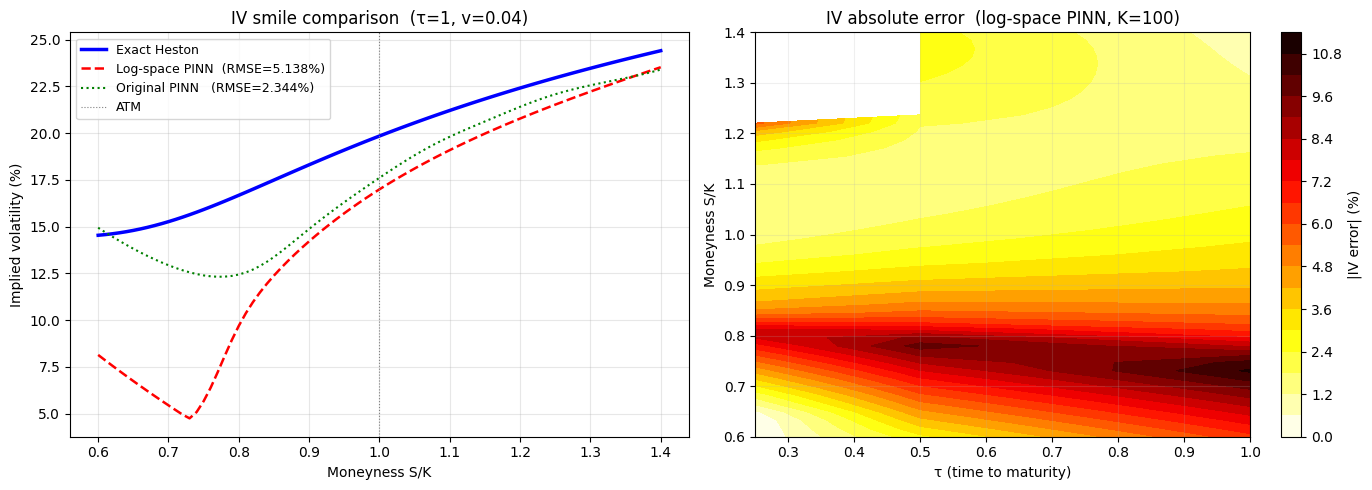

In [ ]:
def implied_vol_nr(price, S, K, r, tau, tol=1e-8, max_iter=50):
    price = float(price); S = float(S); K = float(K)
    if tau <= 1e-12:
        return np.nan
    intrinsic = max(S - K * math.exp(-r * tau), 0.0)
    if price < intrinsic - 1e-4 or price > S + 1e-4:
        return np.nan
    price = max(price, intrinsic + 1e-10)

    vol = max(0.20, math.sqrt(abs(2 * abs(math.log(S / K)) / tau)))
    vol = min(vol, 3.0)

    for _ in range(max_iter):
        if not (1e-8 < vol < 10.0):
            break
        sv = vol * math.sqrt(tau)
        d1 = (math.log(S / K) + (r + 0.5 * vol**2) * tau) / sv
        d2 = d1 - sv
        bs   = S * norm_cdf(d1) - K * math.exp(-r * tau) * norm_cdf(d2)
        vega = S * math.sqrt(tau) / math.sqrt(2 * math.pi) * math.exp(-0.5 * d1**2)
        if vega < 1e-12:
            break
        diff = bs - price
        if abs(diff) < tol:
            return vol
        vol = max(1e-8, min(vol - diff / vega, 10.0))
    return vol


def iv_surface(model, K_list, tau_list, S_arr, r, v0, xi_min, xi_max, device, model_label="PINN"):
    model.eval()
    out = {}
    for K_t in K_list:
        for tau_val in tau_list:
            xi_arr   = np.log(S_arr / K_t)
            in_dom   = (xi_arr >= xi_min) & (xi_arr <= xi_max)
            S_v      = S_arr[in_dom]
            xi_valid = xi_arr[in_dom]

            xi_t  = torch.tensor(xi_valid.reshape(-1,1), dtype=torch.float32, device=device)
            vt    = torch.full_like(xi_t, float(v0))
            taut  = torch.full_like(xi_t, float(tau_val))
            with torch.no_grad():
                u_pred = model(xi_t, vt, taut).cpu().numpy().flatten()
            pinn_prices  = K_t * u_pred
            exact_prices = heston.price_grid(S_v, K_t, v0, tau_val)

            iv_p = np.array([implied_vol_nr(p, S, K_t, r, tau_val)
                             for p, S in zip(pinn_prices, S_v)])
            iv_e = np.array([implied_vol_nr(p, S, K_t, r, tau_val)
                             for p, S in zip(exact_prices, S_v)])

            out[(K_t, tau_val)] = {
                "moneyness":  S_v / K_t,
                "iv_pinn":    iv_p,
                "iv_exact":   iv_e,
                "pinn_prices": pinn_prices,
                "exact_prices": exact_prices,
            }
    return out


# Evaluate IV surface
K_surface   = [80, 90, 100, 110, 120]
tau_surface = [0.25, 0.5, 1.0]
S_iv_arr    = np.linspace(40, 200, 161)

surf_ls   = iv_surface(model_ls, K_surface, tau_surface, S_iv_arr, r, v0, xi_min_ls, xi_max_ls, device, "PINN-LS")

# Print summary table
print("=" * 75)
print("IV Surface – log-space PINN vs exact Heston")
print("=" * 75)
print(f"  {'K':>5}  {'τ':>5}  {'IV RMSE (%)':>12}  {'MaxErr (%)':>12}  "
      f"{'Pts':>5}")

for tau_val in tau_surface:
    for K_t in K_surface:
        d    = surf_ls[(K_t, tau_val)]
        valid = (~np.isnan(d["iv_pinn"]) & ~np.isnan(d["iv_exact"])
                 & (d["iv_exact"] > 0.005))
        if valid.sum() < 3:
            continue
        err    = d["iv_pinn"][valid] - d["iv_exact"][valid]
        rmse   = np.sqrt(np.mean(err**2))
        maxerr = np.max(np.abs(err))
        print(f"  K={K_t:5.0f}  τ={tau_val:.2f}  "
              f"RMSE={100*rmse:10.4f}%  MaxErr={100*maxerr:10.4f}%  "
              f"pts={valid.sum():4d}")
    print()

# IV smile comparison: log-space PINN vs original PINN vs Heston 
print("\nIV smile comparison at t=0, tau=1 (full maturity), v0=0.04")
tau_plot = 1.0
S_iv_plot = np.linspace(60, 140, 81)

# Log-space PINN
xi_plot = np.clip(np.log(S_iv_plot / K), xi_min_ls, xi_max_ls)
xi_t  = torch.tensor(xi_plot.reshape(-1,1), dtype=torch.float32, device=device)
v_t   = torch.full_like(xi_t, float(v0))
tau_t = torch.full_like(xi_t, float(tau_plot))
with torch.no_grad():
    u_ls = model_ls(xi_t, v_t, tau_t).cpu().numpy().flatten()
pinn_ls_prices = K * u_ls

# Original PINN 
S_t2 = torch.tensor(S_iv_plot.reshape(-1,1), dtype=torch.float32, device=device)
v_t2 = torch.full_like(S_t2, float(v0))
t_t2 = torch.zeros_like(S_t2)  # t=0
with torch.no_grad():
    pinn_orig_prices = model_eval(S_t2, v_t2, t_t2).cpu().numpy().flatten()

exact_iv_prices = heston.price_grid(S_iv_plot, K, v0, tau_plot)

iv_ls   = np.array([implied_vol_nr(p, S, K, r, tau_plot) for p, S in zip(pinn_ls_prices, S_iv_plot)])
iv_orig = np.array([implied_vol_nr(p, S, K, r, tau_plot) for p, S in zip(pinn_orig_prices, S_iv_plot)])
iv_ex   = np.array([implied_vol_nr(p, S, K, r, tau_plot) for p, S in zip(exact_iv_prices, S_iv_plot)])

valid_ls   = ~np.isnan(iv_ls)   & ~np.isnan(iv_ex)
valid_orig = ~np.isnan(iv_orig) & ~np.isnan(iv_ex)

rmse_ls   = np.sqrt(np.mean((iv_ls[valid_ls]   - iv_ex[valid_ls]  )**2))
rmse_orig = np.sqrt(np.mean((iv_orig[valid_orig] - iv_ex[valid_orig])**2))
print(f"  Original PINN  IV RMSE = {100*rmse_orig:.4f}%")
print(f"  Log-space PINN IV RMSE = {100*rmse_ls:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(S_iv_plot[valid_ls] / K, 100 * iv_ex[valid_ls],
        "b-", lw=2.5, label="Exact Heston")
ax.plot(S_iv_plot[valid_ls] / K, 100 * iv_ls[valid_ls],
        "r--", lw=1.8, label=f"Log-space PINN  (RMSE={100*rmse_ls:.3f}%)")
ax.plot(S_iv_plot[valid_orig] / K, 100 * iv_orig[valid_orig],
        "g:", lw=1.5, label=f"Original PINN   (RMSE={100*rmse_orig:.3f}%)")
ax.axvline(1.0, color="gray", ls=":", lw=0.8, label="ATM")
ax.set_xlabel("Moneyness S/K"); ax.set_ylabel("Implied volatility (%)")
ax.set_title(f"IV smile comparison  (τ=1, v={v0})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# IV surface heatmap (log-space PINN, K=100)
ax2 = axes[1]
tau_hm = np.array(tau_surface)
mono_hm = np.linspace(0.6, 1.4, 50)
S_hm    = K * mono_hm

iv_hm_pinn  = np.full((len(mono_hm), len(tau_hm)), np.nan)
iv_hm_exact = np.full((len(mono_hm), len(tau_hm)), np.nan)

with torch.no_grad():
    for j, tau_val in enumerate(tau_hm):
        xi_hm = np.clip(np.log(S_hm / K), xi_min_ls, xi_max_ls)
        xi_t  = torch.tensor(xi_hm.reshape(-1,1), dtype=torch.float32, device=device)
        v_t   = torch.full_like(xi_t, float(v0))
        tau_t = torch.full_like(xi_t, float(tau_val))
        u_hm  = model_ls(xi_t, v_t, tau_t).cpu().numpy().flatten()
        pp    = K * u_hm
        ep    = heston.price_grid(S_hm, K, v0, tau_val)
        for i, (S, p, e) in enumerate(zip(S_hm, pp, ep)):
            iv_hm_pinn[i,  j] = implied_vol_nr(p, S, K, r, tau_val) or np.nan
            iv_hm_exact[i, j] = implied_vol_nr(e, S, K, r, tau_val) or np.nan

iv_err_hm = 100 * np.abs(iv_hm_pinn - iv_hm_exact)
im = ax2.contourf(tau_hm, mono_hm, iv_err_hm, levels=20, cmap="hot_r")
plt.colorbar(im, ax=ax2, label="|IV error| (%)")
ax2.set_xlabel("τ (time to maturity)"); ax2.set_ylabel("Moneyness S/K")
ax2.set_title("IV absolute error  (log-space PINN, K=100)")
ax2.grid(alpha=0.2)

plt.tight_layout(); plt.show()
